In [124]:
import torch
import mlflow
import ast
import pandas as pd
import matplotlib.pyplot as plt
from mlflow.tracking import MlflowClient
import os 
import sys
project_root = os.path.expanduser("~/DLAM-Group6")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from external.xlstm_mixer.xlstm_mixer.models.xlstm_mixer import xLSTMMixer

In [125]:
client = MlflowClient()

df_runs = mlflow.search_runs(
    experiment_names=["single_chunk_forecast", "autoregressive_forecast"]
)

summary_table = df_runs.query("(status=='FINISHED')")#.sort_values(by="metrics.best_val_loss")

In [112]:
summary_table.sort_values(by='metrics.val_MSE_rescaled')

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.val_loss,metrics.best_val_loss,metrics.train_loss,metrics.val_MAE_rescaled,...,params.model.model_kwargs.kwargs.xlstm_embedding_dim,params.training.grad_acc_steps,params.training.grad_acc,tags.mlflow.source.type,tags.mlflow.runName,tags.mlflow.user,tags.mlflow.source.git.commit,tags.mlflow.source.git.repoURL,tags.mlflow.source.git.branch,tags.mlflow.source.name
64,df834903da2748e9843d3f9237c0f90c,1,FINISHED,/home/users1/rkxv/s2673208/DLAM-Group6/submiss...,2026-08-29 21:45:13.547000+00:00,2026-08-29 23:33:19.987000+00:00,0.211748,0.210480,0.096329,2.674830,...,None,None,None,LOCAL,trusting-seal-308,s2673208,98e3d80cd7fccb21ec3b20095b80c11fe8b05b2b,https://github.com/yazidhannachi/DLAM-Group6.git,xlstm-mixer-experiments,src/train.py
23,9e0c09e0ef35401c8976448c214e6d2f,1,FINISHED,/home/users1/rkxv/s2673208/DLAM-Group6/submiss...,2026-08-30 18:04:00.881000+00:00,2026-08-30 20:01:41.730000+00:00,0.207024,0.205936,0.103034,2.588256,...,None,None,None,LOCAL,unequaled-stork-952,s2673208,98e3d80cd7fccb21ec3b20095b80c11fe8b05b2b,https://github.com/yazidhannachi/DLAM-Group6.git,xlstm-mixer-experiments,src/train.py
51,a161f281f5e04c9db5be468fd0093743,1,FINISHED,/home/users1/rkxv/s2673208/DLAM-Group6/submiss...,2026-08-29 23:50:21.227000+00:00,2026-08-30 01:29:32.938000+00:00,0.211901,0.208975,0.111666,2.650488,...,None,None,None,LOCAL,debonair-eel-603,s2673208,98e3d80cd7fccb21ec3b20095b80c11fe8b05b2b,https://github.com/yazidhannachi/DLAM-Group6.git,xlstm-mixer-experiments,src/train.py
65,ff281a9a7db343a2b8c014fa58e494a3,1,FINISHED,/home/users1/rkxv/s2673208/DLAM-Group6/submiss...,2026-08-29 21:44:04.168000+00:00,2026-08-30 02:41:50.388000+00:00,0.215706,0.208236,0.080114,2.647845,...,None,None,None,LOCAL,sneaky-slug-318,s2673208,98e3d80cd7fccb21ec3b20095b80c11fe8b05b2b,https://github.com/yazidhannachi/DLAM-Group6.git,xlstm-mixer-experiments,src/train.py
20,60dde4b5d1fc46e888730a51dee8c1fd,1,FINISHED,/home/users1/rkxv/s2673208/DLAM-Group6/submiss...,2026-08-30 18:06:30.307000+00:00,2026-08-30 20:58:09.593000+00:00,0.209982,0.209429,0.096970,2.628408,...,None,None,None,LOCAL,shivering-fawn-685,s2673208,98e3d80cd7fccb21ec3b20095b80c11fe8b05b2b,https://github.com/yazidhannachi/DLAM-Group6.git,xlstm-mixer-experiments,src/train.py
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,52e413e909a247ac8a240ab47305712d,2,FINISHED,/home/users1/rkxv/s2673208/DLAM-Group6/submiss...,2026-08-29 19:39:36.059000+00:00,2026-08-29 20:36:52.849000+00:00,0.518707,0.442282,0.087315,4.256630,...,None,None,None,LOCAL,skittish-crow-722,s2673208,98e3d80cd7fccb21ec3b20095b80c11fe8b05b2b,https://github.com/yazidhannachi/DLAM-Group6.git,xlstm-mixer-experiments,src/train.py
74,fae8d8690491458e91fd2d3ea99fff54,2,FINISHED,/home/users1/rkxv/s2673208/DLAM-Group6/submiss...,2026-08-29 19:37:54.081000+00:00,2026-08-29 20:00:55.582000+00:00,0.507752,0.463140,0.111899,4.404606,...,None,None,None,LOCAL,sedate-stag-24,s2673208,98e3d80cd7fccb21ec3b20095b80c11fe8b05b2b,https://github.com/yazidhannachi/DLAM-Group6.git,xlstm-mixer-experiments,src/train.py
77,ee1a8cebe4904e4db940eb842722a5bc,2,FINISHED,/home/users1/rkxv/s2673208/DLAM-Group6/submiss...,2026-08-29 19:33:20.469000+00:00,2026-08-29 19:47:43.712000+00:00,0.670220,0.470618,0.134719,4.349521,...,None,None,None,LOCAL,gaudy-finch-567,s2673208,98e3d80cd7fccb21ec3b20095b80c11fe8b05b2b,https://github.com/yazidhannachi/DLAM-Group6.git,xlstm-mixer-experiments,src/train.py
89,86be811216e64307959b4a8b66e65a65,1,FINISHED,/home/users1/rkxv/s2673208/DLAM-Group6/submiss...,2026-08-29 18:42:33.419000+00:00,2026-08-29 22:12:34.828000+00:00,0.876266,0.504652,0.100330,4.557786,...,None,None,None,LOCAL,mercurial-carp-517,s2673208,98e3d80cd7fccb21ec3b20095b80c11fe8b05b2b,https://github.com/yazidhannachi/DLAM-Group6.git,xlstm-mixer-experiments,src/train.py


In [117]:
summary_table.loc[summary_table["run_id"]=="df834903da2748e9843d3f9237c0f90c","params.save_dir"].iloc[0]

path='experiments/xLSTMMixer_c8e42c1b_df834903da2748e9843d3f9237c0f90c/raw_preds.csv'
example_preds = pd.read_csv(path, index_col=0)

In [123]:
summary_table.loc[summary_table["run_id"]=="df834903da2748e9843d3f9237c0f90c","params.shared.pred_len"]

64    6
Name: params.shared.pred_len, dtype: object

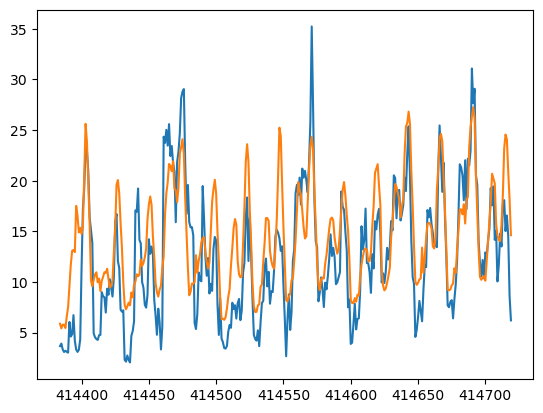

In [119]:
plt.plot(example_preds["target_actual"].tail(336))
plt.plot(example_preds["target_pred"].tail(336))

In [3]:
def get_differing_params(
    df: pd.DataFrame,
    id_cols: list[str] = ["run_id", "tags.mlflow.runName", "experiment_id"],
    dropna_unique: bool = False,
) -> pd.DataFrame:

    if df.empty:
        return df

    param_cols = [c for c in df.columns if c.startswith("params.")]
    valid_id_cols = [c for c in id_cols if c in df.columns]

    differing_param_cols = []
    for col in param_cols:
        if df[col].nunique(dropna=dropna_unique) > 1:
            differing_param_cols.append(col)

    output_cols = valid_id_cols + differing_param_cols

    return df[output_cols]

def plot_subset(subset, param_of_interest):

    fix, axs = plt.subplots(1,2,figsize=(10, 3))

    for _, run in subset.iterrows():
        run_id = run["run_id"]
        run_name = run["tags.mlflow.runName"]
        run_mse = run["metrics.val_MSE_rescaled"]
        poi_value = run[param_of_interest]
        poi_name = param_of_interest.split(".")[-1]
        history_val = client.get_metric_history(run_id, "val_loss")
        steps_val = [m.step for m in history_val]
        values_val = [m.value for m in history_val]

        history_train = client.get_metric_history(run_id, "train_loss")
        steps_train = [m.step for m in history_train]
        values_train = [m.value for m in history_train]
        
        axs[0].plot(steps_val, values_val, label=f"{round(run_mse,2)}, {poi_name}={poi_value}")
        axs[1].plot(steps_train, values_train, label=f"{round(run_mse,2)}, {poi_name}={poi_value}")

        axs[0].set_xlabel("Epoch")
        axs[1].set_xlabel("Epoch")

        axs[0].set_ylabel("Validation Loss")
        axs[1].set_ylabel("Training Loss")

        axs[0].set_ylim(0.1,0.4)
        axs[1].set_ylim(0,0.4)

        axs[0].legend()
        axs[1].legend()

        axs[0].grid(True)
        axs[1].grid(True)

    return fix, axs

def find_comp_candidates(
    run_id: str,
    df: pd.DataFrame,
    param_column: str | None = None,
) -> pd.DataFrame:
    
    if "run_id" not in df.columns:
        raise ValueError("DataFrame must contain a 'run_id' column.")
    if "experiment_id" not in df.columns:
        raise ValueError("DataFrame must contain an 'experiment_id' column.")

    ref_rows = df[df["run_id"] == run_id]
    if len(ref_rows) == 0:
        raise ValueError(f"run_id '{run_id}' not found in dataframe.")
    if len(ref_rows) > 1:
        raise ValueError(f"run_id '{run_id}' appears multiple times in dataframe.")

    ref_row = ref_rows.iloc[0]

    # Only compare params.* columns
    param_cols = [c for c in df.columns if c.startswith("params.")]
    if not param_cols:
        raise ValueError("No columns starting with 'params.' found in dataframe.")

    if param_column is not None:
        if param_column not in param_cols:
            raise ValueError(
                f"Invalid param_column '{param_column}'. It must be one of: {param_cols}"
            )

    # Restrict to same experiment_id
    same_exp = df["experiment_id"] == ref_row["experiment_id"]

    # Compare params columns, treating NaN == NaN as equal
    def equal_with_nan(col):
        return (df[col] == ref_row[col]) | (df[col].isna() & pd.isna(ref_row[col]))

    if param_column is None:
        # Count how many params columns differ from reference
        equal_matrix = pd.DataFrame({col: equal_with_nan(col) for col in param_cols})
        num_different = (~equal_matrix).sum(axis=1)

        mask = same_exp & (num_different == 1)
    else:
        # Must differ in the chosen column...
        differs_target = ~equal_with_nan(param_column)

        # ...and match in all other params columns
        other_cols = [c for c in param_cols if c != param_column]
        if other_cols:
            equal_others = pd.DataFrame({col: equal_with_nan(col) for col in other_cols}).all(axis=1)
        else:
            equal_others = pd.Series(True, index=df.index)

        mask = same_exp & differs_target & equal_others

    # Usually you do not want to include the reference row itself;
    # it will not match anyway because it differs in 0 params columns.
    return df[mask].copy()

/tmp/ipykernel_695698/1596436633.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_1.loc[:,"MSE"] = pd.to_numeric(subset_1["metrics.val_MSE_rescaled"])
/tmp/ipykernel_695698/1596436633.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_2.loc[:,"MSE"] = pd.to_numeric(subset_2["metrics.val_MSE_rescaled"])


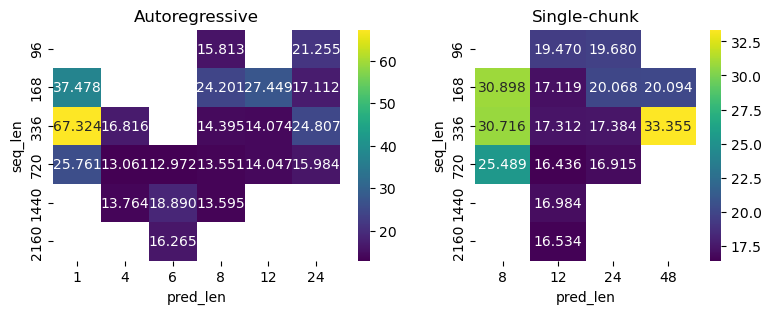

In [127]:
import seaborn as sns
subset_1 = summary_table.query("""experiment_id=='1' &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8' &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1' &\
`params.data.stride`=='12' &\
`params.training.alpha`.isna() &\
`params.training.loss_weighted`.isna() &\
`params.shared.criterion`=='Huber' &\
`params.model.model_kwargs.kwargs.xlstm_embedding_dim`.isna() &\
`params.seed`.isna()""")

subset_2 = summary_table.query("""experiment_id=='2' &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8' &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1' &\
`params.data.stride`=='12' &\
`params.training.alpha`.isna() &\
`params.training.loss_weighted`.isna() &\
`params.shared.criterion`=='Huber' &\
`params.model.model_kwargs.kwargs.xlstm_embedding_dim`.isna() &\
`params.seed`.isna()""")

subset_1.loc[:,"params.shared.pred_len"] = pd.to_numeric(subset_1["params.shared.pred_len"])
subset_1.loc[:,"params.shared.seq_len"] = pd.to_numeric(subset_1["params.shared.seq_len"])
subset_1.loc[:,"MSE"] = pd.to_numeric(subset_1["metrics.val_MSE_rescaled"])

subset_2.loc[:,"params.shared.pred_len"] = pd.to_numeric(subset_2["params.shared.pred_len"])
subset_2.loc[:,"params.shared.seq_len"] = pd.to_numeric(subset_2["params.shared.seq_len"])
subset_2.loc[:,"MSE"] = pd.to_numeric(subset_2["metrics.val_MSE_rescaled"])

heatmap_df_1=subset_1.pivot_table(columns='params.shared.pred_len', index='params.shared.seq_len', values='metrics.val_MSE_rescaled')
heatmap_df_2=subset_2.pivot_table(columns='params.shared.pred_len', index='params.shared.seq_len', values='metrics.val_MSE_rescaled')

fig, axs = plt.subplots(1, 2, figsize=(9, 3), width_ratios=[1.3,1])
sns.heatmap(heatmap_df_1, annot=True, fmt=".3f", cmap="viridis", ax=axs[0])
axs[0].set_xlabel("pred_len")
axs[0].set_ylabel("seq_len")
axs[0].set_title("Autoregressive")

sns.heatmap(heatmap_df_2, annot=True, fmt=".3f", cmap="viridis", ax=axs[1])
axs[1].set_xlabel("pred_len")
axs[1].set_ylabel("seq_len")
axs[1].set_title("Single-chunk")
plt.show()

Windows seem to have a big impact on performance => finer search worth it before tuning other parameters

## Follow-up-1

### MSE vs Huber

(0.0, 0.8)

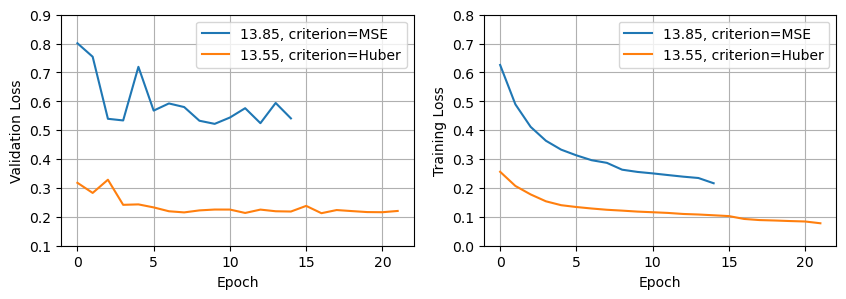

In [32]:
subset = summary_table.query("""`params.shared.seq_len`=='720' &\
`params.shared.pred_len`=='8' &\
`experiment_id`=='1' &\
`params.training.loss_weighted`.isna() &\
`params.data.stride`=='12' &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8'""")
subset
#paths=subset.loc[:,summary_table.columns.to_series().str.startswith("params.save_dir")]
#subset.loc[:,summary_table.columns.to_series().str.startswith("metrics.val_MSE_rescaled")]
fig, axs = plot_subset(subset, param_of_interest="params.shared.criterion")
axs[0].set_ylim(0.1, 0.9)
axs[1].set_ylim(0, 0.8)

### Learning rates

(0.0, 0.5)

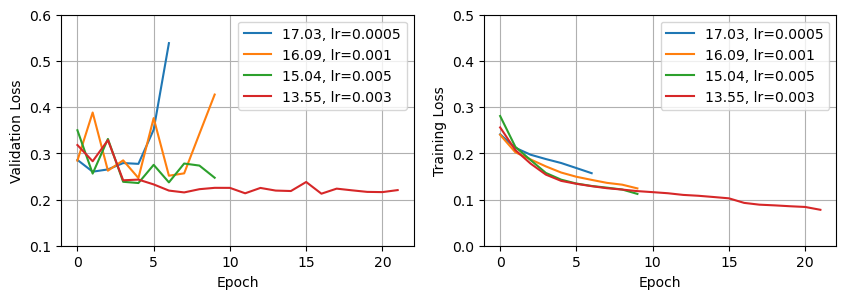

In [33]:
subset = summary_table.query("""`params.shared.seq_len`=='720' &\
`params.shared.pred_len`=='8' &\
`experiment_id`=='1' &\
`params.shared.criterion`=='Huber' &\
`params.training.loss_weighted`.isna() &\
`params.data.stride`=='12' &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8'""")
#paths=subset.loc[:,summary_table.columns.to_series().str.startswith("params.save_dir")]
#subset.loc[:,summary_table.columns.to_series().str.startswith("metrics.val_MSE_rescaled")]
fig, axs = plot_subset(subset, param_of_interest="params.training.optimizer_kwargs.lr")
axs[0].set_ylim(0.1, 0.6)
axs[1].set_ylim(0, 0.5)

(0.0, 0.5)

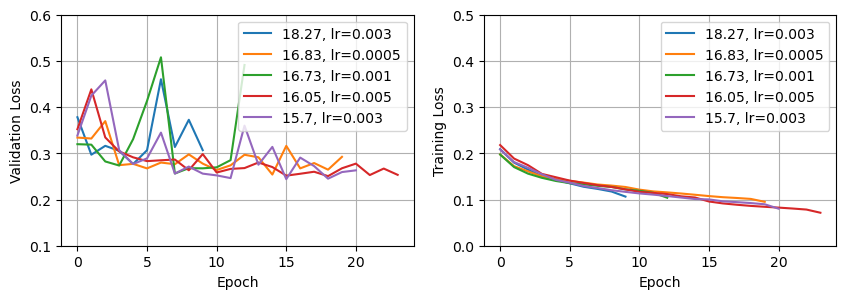

In [42]:
subset = summary_table.query("""`params.shared.seq_len`=='1440' &\
`params.shared.pred_len`=='12' &\
`experiment_id`=='2' &\
`params.shared.criterion`=='Huber' &\
`params.training.loss_weighted`.isna() &\
`params.data.stride`=='12' &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8'""")
#paths=subset.loc[:,summary_table.columns.to_series().str.startswith("params.save_dir")]
#subset.loc[:,summary_table.columns.to_series().str.startswith("metrics.val_MSE_rescaled")]
fig, axs = plot_subset(subset, param_of_interest="params.training.optimizer_kwargs.lr")
axs[0].set_ylim(0.1, 0.6)
axs[1].set_ylim(0, 0.5)

Learning rate also has a bigger impact -> tune finely around 0.003

### Stride

(0.0, 0.5)

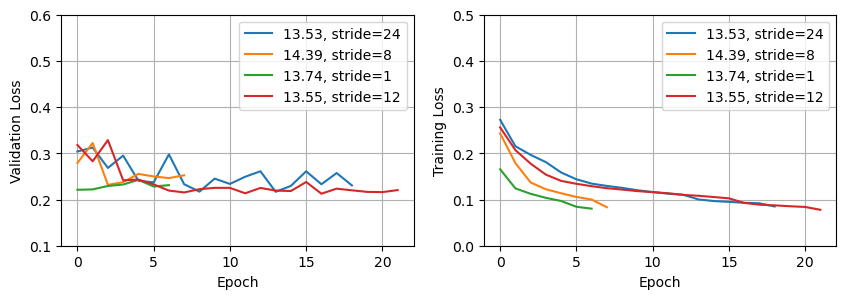

In [34]:
subset = summary_table.query("""`params.shared.seq_len`=='720' &\
`params.shared.pred_len`=='8' &\
`experiment_id`=='1' &\
`params.shared.criterion`=='Huber' &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.training.loss_weighted`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8'""")
#paths=subset.loc[:,summary_table.columns.to_series().str.startswith("params.save_dir")]
#subset.loc[:,summary_table.columns.to_series().str.startswith("metrics.val_MSE_rescaled")]
fig, axs = plot_subset(subset, param_of_interest="params.data.stride")
axs[0].set_ylim(0.1, 0.6)
axs[1].set_ylim(0, 0.5)

(0.0, 0.5)

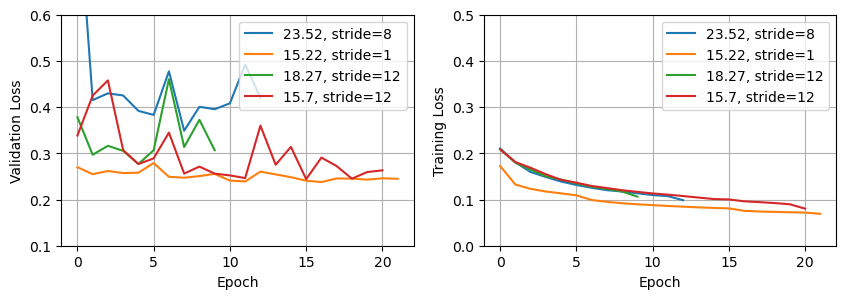

In [45]:
subset = summary_table.query("""`params.shared.seq_len`=='1440' &\
`params.shared.pred_len`=='12' &\
`experiment_id`=='2' &\
`params.shared.criterion`=='Huber' &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.training.loss_weighted`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8'""")
#paths=subset.loc[:,summary_table.columns.to_series().str.startswith("params.save_dir")]
#subset.loc[:,summary_table.columns.to_series().str.startswith("metrics.val_MSE_rescaled")]
fig, axs = plot_subset(subset, param_of_interest="params.data.stride")
axs[0].set_ylim(0.1, 0.6)
axs[1].set_ylim(0, 0.5)

Try stride=6?

### Weighted loss

(0.0, 0.5)

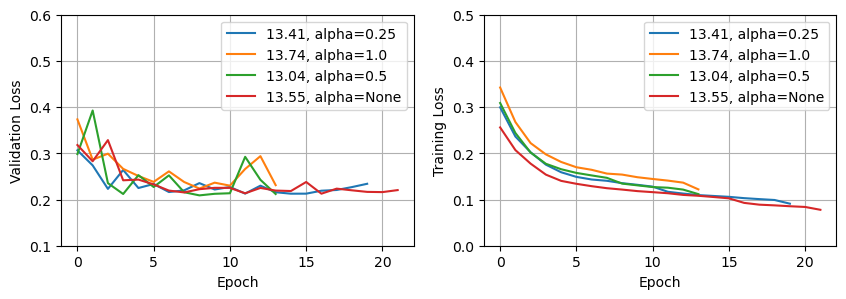

In [35]:
subset = summary_table.query("""`params.shared.seq_len`=='720' &\
`params.shared.pred_len`=='8' &\
`experiment_id`=='1' &\
`params.data.stride`=='12' &\
`params.shared.criterion`=='Huber' &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8'""")
#paths=subset.loc[:,summary_table.columns.to_series().str.startswith("params.save_dir")]
#subset.loc[:,summary_table.columns.to_series().str.startswith("metrics.val_MSE_rescaled")]
fig, axs = plot_subset(subset, param_of_interest="params.training.alpha")
axs[0].set_ylim(0.1, 0.6)
axs[1].set_ylim(0, 0.5)

(0.0, 0.5)

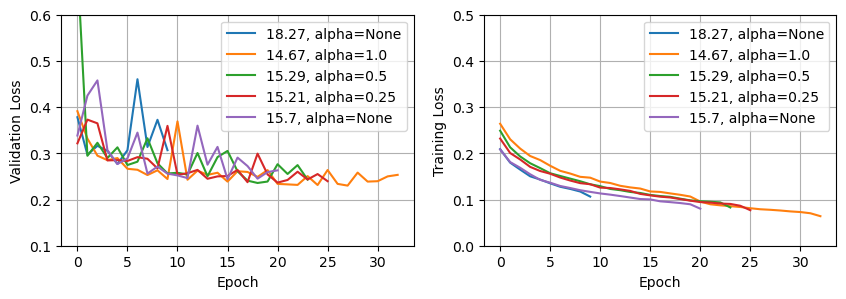

In [47]:
subset = summary_table.query("""`params.shared.seq_len`=='1440' &\
`params.shared.pred_len`=='12' &\
`experiment_id`=='2' &\
`params.data.stride`=='12' &\
`params.shared.criterion`=='Huber' &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8'""")
#paths=subset.loc[:,summary_table.columns.to_series().str.startswith("params.save_dir")]
#subset.loc[:,summary_table.columns.to_series().str.startswith("metrics.val_MSE_rescaled")]
fig, axs = plot_subset(subset, param_of_interest="params.training.alpha")
axs[0].set_ylim(0.1, 0.6)
axs[1].set_ylim(0, 0.5)

Advantage of $\alpha=0.5$ not entirely clear because validation loss is more noisy => try both for continuing

### Heads

(0.0, 0.5)

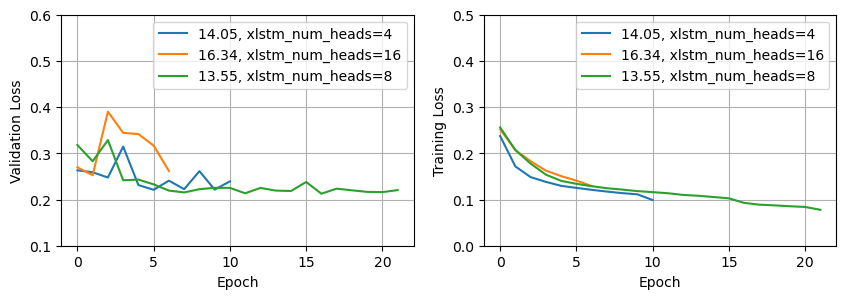

In [37]:
subset = summary_table.query("""`params.shared.seq_len`=='720' &\
`params.shared.pred_len`=='8' &\
`experiment_id`=='1' &\
`params.data.stride`=='12' &\
`params.shared.criterion`=='Huber' &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.training.alpha`.isna()""")
#paths=subset.loc[:,summary_table.columns.to_series().str.startswith("params.save_dir")]
#subset.loc[:,summary_table.columns.to_series().str.startswith("metrics.val_MSE_rescaled")]
fig, axs = plot_subset(subset, param_of_interest="params.model.model_kwargs.kwargs.xlstm_num_heads")
axs[0].set_ylim(0.1, 0.6)
axs[1].set_ylim(0, 0.5)

4 heads could be worth trying as well, hard to tell benefit ebcause of noise and early stopping

## Num blocks

(0.0, 0.5)

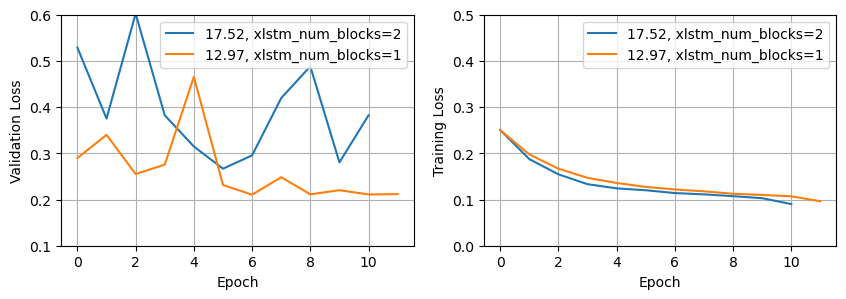

In [51]:
subset = summary_table.query("""`params.shared.seq_len`=='720' &\
`params.shared.pred_len`=='6' &\
`experiment_id`=='1' &\
`params.data.stride`=='12' &\
`params.shared.criterion`=='Huber' &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.training.alpha`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_embedding_dim`.isna()""")
#paths=subset.loc[:,summary_table.columns.to_series().str.startswith("params.save_dir")]
#subset.loc[:,summary_table.columns.to_series().str.startswith("metrics.val_MSE_rescaled")]
fig, axs = plot_subset(subset, param_of_interest="params.model.model_kwargs.kwargs.xlstm_num_blocks")
axs[0].set_ylim(0.1, 0.6)
axs[1].set_ylim(0, 0.5)

## Embedding dim

(0.0, 0.5)

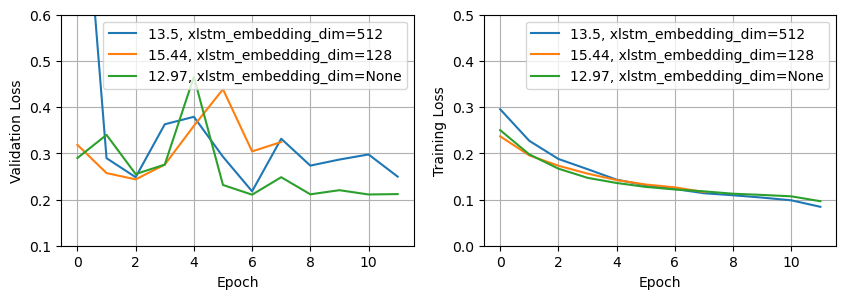

In [54]:
subset = summary_table.query("""`params.shared.seq_len`=='720' &\
`params.shared.pred_len`=='6' &\
`experiment_id`=='1' &\
`params.data.stride`=='12' &\
`params.shared.criterion`=='Huber' &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.training.alpha`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1'""")
#paths=subset.loc[:,summary_table.columns.to_series().str.startswith("params.save_dir")]
#subset.loc[:,summary_table.columns.to_series().str.startswith("metrics.val_MSE_rescaled")]
fig, axs = plot_subset(subset, param_of_interest="params.model.model_kwargs.kwargs.xlstm_embedding_dim")
axs[0].set_ylim(0.1, 0.6)
axs[1].set_ylim(0, 0.5)

## Follow-up 2

### Windows

/tmp/ipykernel_695698/2132566336.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_1.loc[:,"MSE"] = pd.to_numeric(subset_1["metrics.val_MSE_rescaled"])
/tmp/ipykernel_695698/2132566336.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_2.loc[:,"MSE"] = pd.to_numeric(subset_2["metrics.val_MSE_rescaled"])


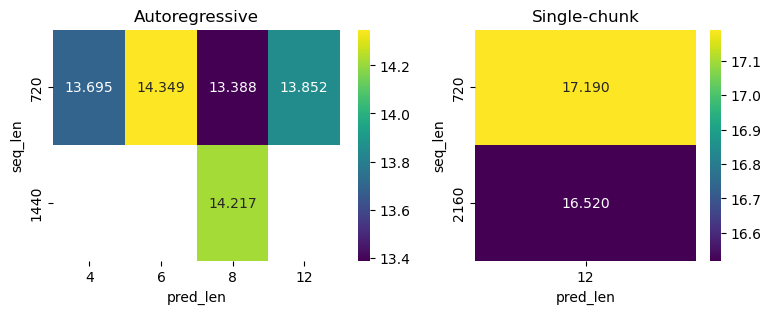

In [126]:
subset_1 = summary_table.query("""experiment_id=='1' &\
~`params.seed`.isna() &\
`params.training.alpha`=='0.25' &\
`params.training.optimizer_kwargs.weight_decay`=='0' &\
`params.model.prior`.isna()""")

subset_2 = summary_table.query("""experiment_id=='2' &\
~`params.seed`.isna()""")

subset_1.loc[:,"params.shared.pred_len"] = pd.to_numeric(subset_1["params.shared.pred_len"])
subset_1.loc[:,"params.shared.seq_len"] = pd.to_numeric(subset_1["params.shared.seq_len"])
subset_1.loc[:,"MSE"] = pd.to_numeric(subset_1["metrics.val_MSE_rescaled"])

subset_2.loc[:,"params.shared.pred_len"] = pd.to_numeric(subset_2["params.shared.pred_len"])
subset_2.loc[:,"params.shared.seq_len"] = pd.to_numeric(subset_2["params.shared.seq_len"])
subset_2.loc[:,"MSE"] = pd.to_numeric(subset_2["metrics.val_MSE_rescaled"])

heatmap_df_1=subset_1.pivot_table(columns='params.shared.pred_len', index='params.shared.seq_len', values='metrics.val_MSE_rescaled')
heatmap_df_2=subset_2.pivot_table(columns='params.shared.pred_len', index='params.shared.seq_len', values='metrics.val_MSE_rescaled')

fig, axs = plt.subplots(1, 2, figsize=(9, 3), width_ratios=[1.3,1])
sns.heatmap(heatmap_df_1, annot=True, fmt=".3f", cmap="viridis", ax=axs[0])
axs[0].set_xlabel("pred_len")
axs[0].set_ylabel("seq_len")
axs[0].set_title("Autoregressive")

sns.heatmap(heatmap_df_2, annot=True, fmt=".3f", cmap="viridis", ax=axs[1])
axs[1].set_xlabel("pred_len")
axs[1].set_ylabel("seq_len")
axs[1].set_title("Single-chunk")
plt.show()

### Weight decay

(0.0, 0.5)

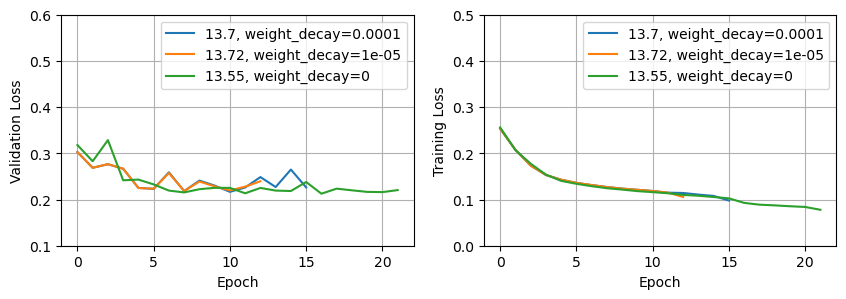

In [103]:
subset = summary_table.query("""`params.shared.seq_len`=='720' &\
`params.shared.pred_len`=='8' &\
`experiment_id`=='1' &\
`params.data.stride`=='12' &\
`params.shared.criterion`=='Huber' &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.training.alpha`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1' &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8' &\
`params.model.prior`.isna()""")
#paths=subset.loc[:,summary_table.columns.to_series().str.startswith("params.save_dir")]
#subset.loc[:,summary_table.columns.to_series().str.startswith("metrics.val_MSE_rescaled")]
fig, axs = plot_subset(subset, param_of_interest="params.training.optimizer_kwargs.weight_decay")
axs[0].set_ylim(0.1, 0.6)
axs[1].set_ylim(0, 0.5)

### Fourier prior

(0.0, 0.5)

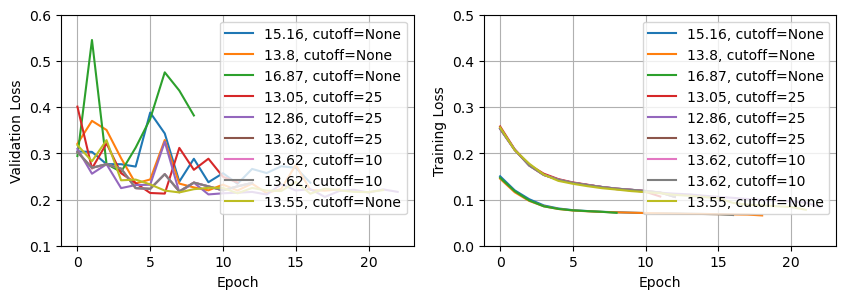

In [129]:
subset = summary_table.query("""`params.shared.seq_len`=='720' &\
`params.shared.pred_len`=='8' &\
`experiment_id`=='1' &\
`params.data.stride`=='12' &\
`params.shared.criterion`=='Huber' &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.training.alpha`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1' &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8' &\
`params.training.optimizer_kwargs.weight_decay`=='0'""")
#paths=subset.loc[:,summary_table.columns.to_series().str.startswith("params.save_dir")]
#subset.loc[:,summary_table.columns.to_series().str.startswith("metrics.val_MSE_rescaled")]
fig, axs = plot_subset(subset, param_of_interest="params.model.base_model_kwargs.cutoff")
axs[0].set_ylim(0.1, 0.6)
axs[1].set_ylim(0, 0.5)

### Embedding dim

(0.0, 0.5)

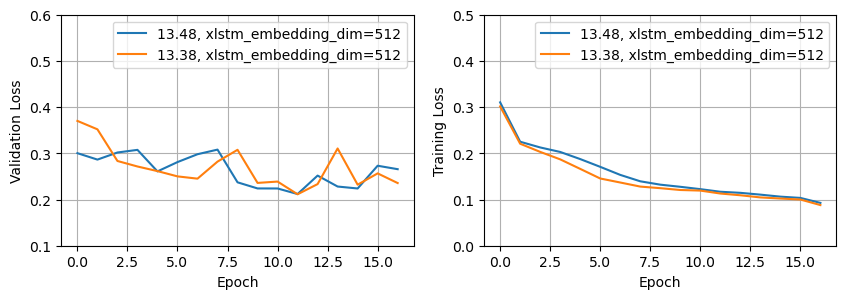

In [137]:
subset = summary_table.query("""`params.shared.seq_len`=='720' &\
`params.shared.pred_len`=='8' &\
`experiment_id`=='1' &\
`params.data.stride`=='24' &\
`params.shared.criterion`=='Huber' &\
`params.training.optimizer_kwargs.lr`=='0.002' &\
`params.training.alpha`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1' &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8'""")
#paths=subset.loc[:,summary_table.columns.to_series().str.startswith("params.save_dir")]
#subset.loc[:,summary_table.columns.to_series().str.startswith("metrics.val_MSE_rescaled")]
fig, axs = plot_subset(subset, param_of_interest="params.model.model_kwargs.kwargs.xlstm_embedding_dim")
axs[0].set_ylim(0.1, 0.6)
axs[1].set_ylim(0, 0.5)

In [140]:
subset['params.save_dir'].iloc[0]

'experiments/xLSTMMixer_ecb07095_28b5063f72b34995bd93969923d77b15'

In [143]:
data = 'experiments/xLSTMMixer_ecb07095_28b5063f72b34995bd93969923d77b15/raw_preds.csv'
data_df = pd.read_csv(data, index_col=0)

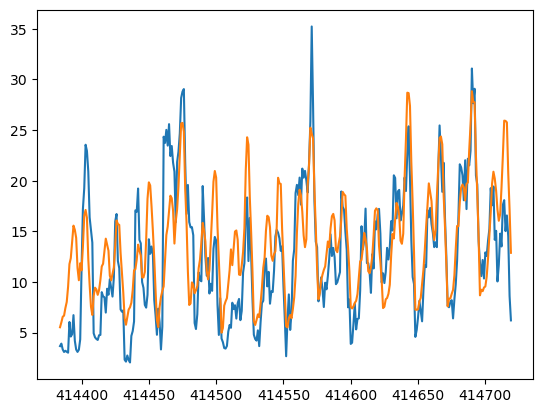

In [145]:
plt.plot(data_df["target_actual"].tail(336))
plt.plot(data_df["target_pred"].tail(336))

(0.0, 0.5)

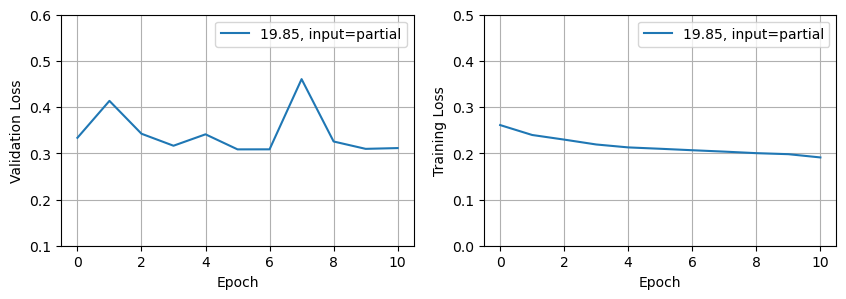

In [134]:
subset = summary_table.query("""`params.shared.seq_len`=='720' &\
`params.shared.pred_len`=='8' &\
`experiment_id`=='1' &\
`params.data.stride`=='12' &\
`params.shared.criterion`=='Huber' &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.data.input`=='partial'""")
#paths=subset.loc[:,summary_table.columns.to_series().str.startswith("params.save_dir")]
#subset.loc[:,summary_table.columns.to_series().str.startswith("metrics.val_MSE_rescaled")]
fig, axs = plot_subset(subset, param_of_interest="params.data.input")
axs[0].set_ylim(0.1, 0.6)
axs[1].set_ylim(0, 0.5)

(0.0, 0.5)

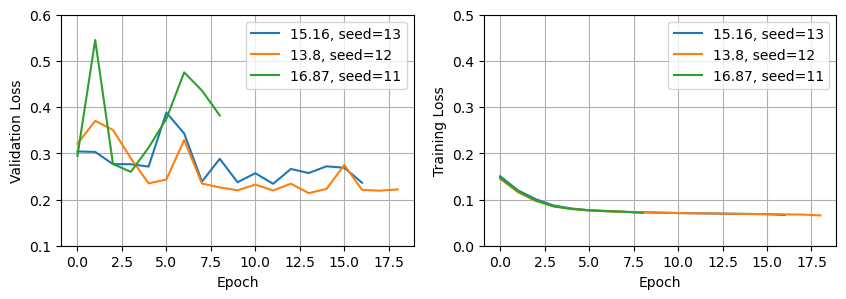

In [136]:
subset = summary_table.query("""`params.training.loss_on`=='all'""")

fig, axs = plot_subset(subset, param_of_interest="params.seed")
axs[0].set_ylim(0.1, 0.6)
axs[1].set_ylim(0, 0.5)

In [71]:
subset_1.loc[:,subset_1.columns.to_series().str.startswith("metrics")]

,metrics.val_loss,metrics.best_val_loss,metrics.train_loss,metrics.val_MAE_rescaled,metrics.val_MSE_rescaled,metrics.lr
3,0.236448,0.217935,0.101006,2.686846,13.851021,0.00150
4,0.254307,0.220584,0.110461,2.711813,14.038074,0.00150
5,0.246615,0.229388,0.098162,2.746432,14.763101,0.00150
6,0.233063,0.214700,0.096845,2.695506,13.309594,0.00075
7,0.233518,0.218028,0.123679,2.728508,13.635084,0.00150
8,0.209982,0.209429,0.096970,2.628408,13.220033,0.00150
9,0.375572,0.253780,0.120597,2.936655,16.463461,0.00150
10,0.297748,0.221432,0.095613,2.759139,13.564338,0.00075
11,0.207024,0.205936,0.103034,2.588256,13.018095,0.00150
13,0.217004,0.211229,0.118233,2.610370,13.528425,0.00150


In [64]:
# PER UNIT ERROR DISTRIBUTION

subset = summary_table.query("""`params.model.model_kwargs.kwargs.xlstm_dropout`=='0' &\
`params.training.optimizer_kwargs.weight_decay`=='0' &\
`params.data.stride`=='1' &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1' &\
`params.shared.seq_len`=='168' &\
`params.shared.pred_len`=='24' &\
`params.shared.criterion`=='MSE' &\
(`params.training.ar_steps`=='0' | `params.training.ar_steps`=='4') &\
`params.model.prior`!='Fourier' &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8'  &\
`params.model.model_kwargs.kwargs.xlstm_conv1d_kernel_size`.isna() &\
`params.training.batch_size`=='128'""")
paths=subset.loc[:,summary_table.columns.to_series().str.startswith("params.save_dir")]
subset.loc[:,summary_table.columns.to_series().str.startswith("metrics.val_MSE_rescaled")]

,metrics.val_MSE_rescaled
60,17.102318
101,17.293928


In [72]:

#run_id = "fab8d83534eb497b8b8a806724eb462d"
pred_path = paths.iloc[0,:].values[0]
raw_preds = pd.read_csv(os.path.join(pred_path, "raw_preds.csv"))
raw_preds_eval = raw_preds.groupby("series_id").tail(336)
mse = ((raw_preds_eval["target_actual"] - raw_preds_eval["target_pred"]) ** 2).mean()
mse_per_series = ((raw_preds_eval["target_actual"] - raw_preds_eval["target_pred"]) ** 2)
print("MSE:", mse)
mae = (raw_preds_eval["target_actual"] - raw_preds_eval["target_pred"]).abs().mean()
print("MAE:", mae)
#raw_preds_actual['mse'] = ((raw_preds_actual["target_actual"]-raw_preds_actual["target_pred"])**2)
#groups = raw_preds.groupby('series_id').mean()
#groups
#groups.sort_values(by='mse', ascending=False)
#((raw_preds_actual["target_actual"]-raw_preds_actual["target_pred"])**2).mean()

MSE: 18.394529412909996
MAE: 3.152593144014277


In [74]:
raw_preds = pd.read_csv(os.path.join(pred_path, "raw_preds.csv"))
raw_preds_eval = raw_preds.groupby("series_id").tail(336)

mse_per_series = raw_preds_eval.groupby("series_id").apply(
    lambda g: ((g["target_actual"] - g["target_pred"]) ** 2).mean()
)

print(mse_per_series)

series_id
unit_000    16.141271
unit_001    20.275975
unit_002    12.230124
unit_003    10.401645
unit_004    30.156374
              ...    
unit_091    18.571313
unit_092    20.394301
unit_093    24.159177
unit_094    19.035064
unit_095    28.343250
Length: 96, dtype: float64


/tmp/ipykernel_301597/2990253334.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mse_per_series = raw_preds_eval.groupby("series_id").apply(


(array([ 5.,  6.,  9., 10., 12.,  5.,  9., 10.,  3.,  9.,  3.,  6.,  4.,
         1.,  1.,  0.,  1.,  0.,  1.,  1.]),
 array([ 5.05746942,  7.0975363 ,  9.13760318, 11.17767006, 13.21773694,
        15.25780382, 17.29787071, 19.33793759, 21.37800447, 23.41807135,
        25.45813823, 27.49820511, 29.53827199, 31.57833887, 33.61840575,
        35.65847263, 37.69853951, 39.73860639, 41.77867327, 43.81874015,
        45.85880704]),
 <BarContainer object of 20 artists>)

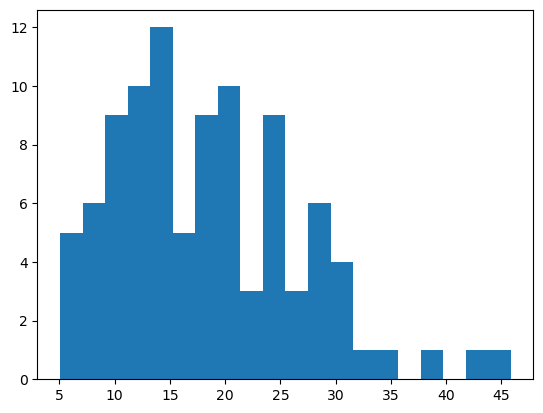

In [77]:
plt.hist(mse_per_series, bins=20)

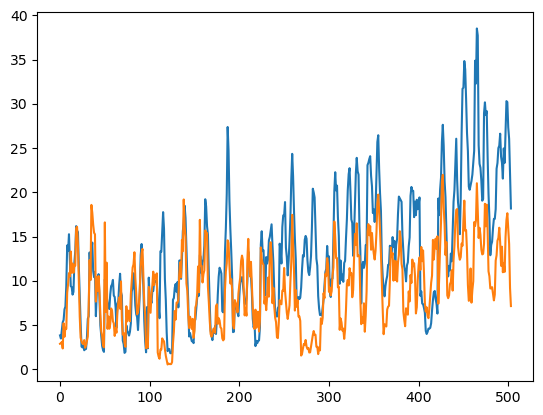

In [53]:
import numpy as np
plt.plot(np.arange(504),raw_preds.loc[raw_preds["series_id"]=='unit_051',"target_actual"])
plt.plot(np.arange(504),raw_preds.loc[raw_preds["series_id"]=='unit_034',"target_actual"])

difficult units:

['unit_007', 'unit_021', 'unit_042', 'unit_052', 'unit_056', 'unit_062',
       'unit_065', 'unit_070', 'unit_074', 'unit_079']



In [29]:
## ARIMA only run 950a33e9ddee4e0890706ddabd0684ac, MSE 8.84

arima_only=summary_table.query("run_id=='950a33e9ddee4e0890706ddabd0684ac'")

In [24]:
summary_table[['params.model.prior','metrics.val_MSE_rescaled']].sort_values(by='metrics.val_MSE_rescaled')

,params.model.prior,metrics.val_MSE_rescaled
2,Fourier,15.643111
95,None,15.771223
18,Fourier,15.869626
1,Fourier,15.890836
15,Fourier,15.947146
...,...,...
136,None,NaN
137,None,NaN
138,None,NaN
139,None,NaN


## Huber vs MSE

In [25]:
subset = summary_table.query("""`params.model.model_kwargs.kwargs.xlstm_dropout`=='0' & `params.training.optimizer_kwargs.weight_decay`=='0'""")
metrics_list = []
for run in subset["run_id"].values:
    try:
        path=client.download_artifacts(run_id=run, path="metrics.csv")
        metrics = pd.read_csv(path, index_col=0)
        metrics["run_id"] = run
        metrics["runName"] = subset.loc[subset["run_id"]==run,"tags.mlflow.runName"].values[0]
        metrics["trained_on"] = subset.loc[subset["run_id"]==run,"params.training.criterion"].values[0]
        metrics["experiment_id"] = subset.loc[subset["run_id"]==run,"experiment_id"].values[0]

        metrics_list.append(metrics)
    except Exception:
        continue

total_metrics_df = pd.concat(metrics_list)

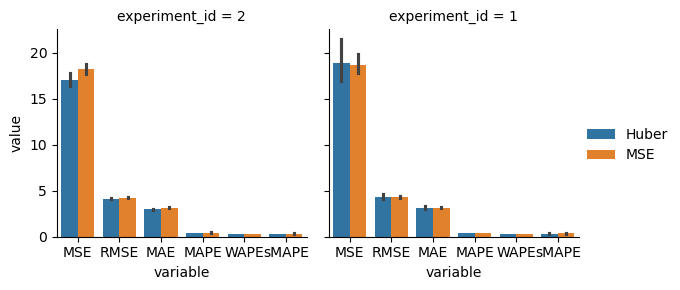

In [27]:
import seaborn as sns
subset= summary_table.query("`params.model.prior`!='Fourier'")
plot_df=total_metrics_df.loc[total_metrics_df["run_id"].isin(subset["run_id"]),:]
plot_df = total_metrics_df.melt(id_vars=["trained_on", "run_id", "runName", "experiment_id"])
#ig, ax = plt.subplots(1,1,figsize=(4,4))
g = sns.FacetGrid(data=plot_df, col='experiment_id')
g.map_dataframe(sns.barplot, x="variable", y="value", hue="trained_on", palette='tab10')
g.add_legend()
#ax.set_yscale('log')

## Window sizes

In [35]:
subset = summary_table.query("""`params.model.model_kwargs.kwargs.xlstm_dropout`=='0' &\
`params.training.optimizer_kwargs.weight_decay`=='0' &\
`params.data.stride`=='1' &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1' &\
`params.shared.seq_len`=='168' &\
`params.shared.criterion`=='MSE' &\
(`params.training.ar_steps`=='0' | `params.training.ar_steps`=='4') &\
`params.model.prior`!='Fourier' &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8'  &\
`params.model.model_kwargs.kwargs.xlstm_conv1d_kernel_size`.isna() &\
`params.training.batch_size`=='128'""")
#subset.loc[:,summary_table.columns.to_series().str.startswith("params.training")]

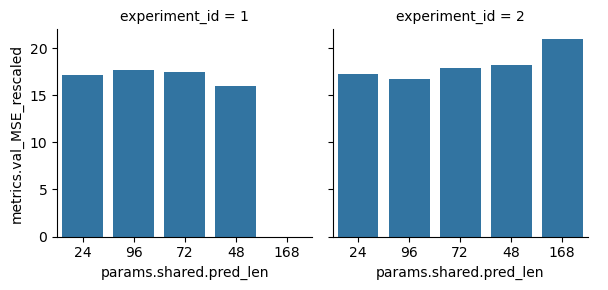

In [36]:
g = sns.FacetGrid(data=subset, col='experiment_id')
g.map_dataframe(sns.barplot, x="params.shared.pred_len", y="metrics.val_MSE_rescaled")
g.add_legend()

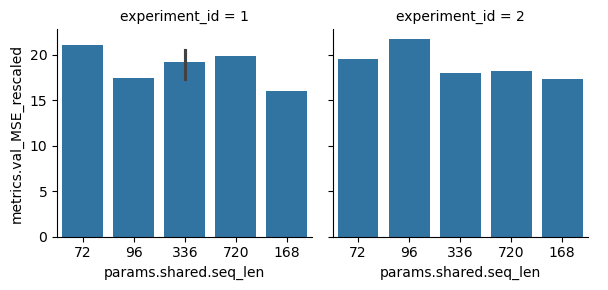

In [37]:
subset = summary_table.query("""`params.model.model_kwargs.kwargs.xlstm_dropout`=='0' &\
`params.training.optimizer_kwargs.weight_decay`=='0' &\
`params.data.stride`=='1' &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1' &\
((`params.shared.pred_len`=='24' & experiment_id=='2') | (`params.shared.pred_len`=='48' & experiment_id=='1')) &\
`params.shared.criterion`=='MSE' &\
(`params.training.ar_steps`=='0' | `params.training.ar_steps`=='4') &\
`params.model.prior`!='Fourier' &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8'  &\
`params.model.model_kwargs.kwargs.xlstm_conv1d_kernel_size`.isna() &\
`params.training.batch_size`=='128'""")
#subset.loc[:,summary_table.columns.to_series().str.startswith("params")]
g = sns.FacetGrid(data=subset, col='experiment_id')
g.map_dataframe(sns.barplot, x="params.shared.seq_len", y="metrics.val_MSE_rescaled")
g.add_legend()

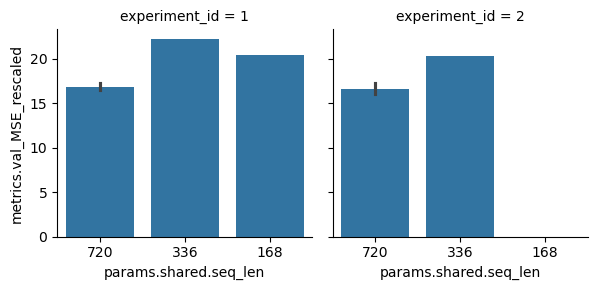

In [40]:
## Fourier prior

subset = summary_table.query("""`params.training.optimizer_kwargs.weight_decay`=='0' &\
`params.shared.criterion`=='Huber' &\
(`params.training.ar_steps`=='0' | `params.training.ar_steps`=='4') &\
`params.model.prior`=='Fourier' &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8'  &\
`params.model.model_kwargs.kwargs.xlstm_conv1d_kernel_size`.isna()""")
#subset.loc[:,summary_table.columns.to_series().str.startswith("params")]
g = sns.FacetGrid(data=subset, col='experiment_id')
g.map_dataframe(sns.barplot, x="params.shared.seq_len", y="metrics.val_MSE_rescaled")
g.add_legend()

## Stride

In [34]:
#summary_table.query("`params.data.stride`=='6'").loc[:,summary_table.columns.to_series().str.startswith("params")]
subset = summary_table.query("""`params.shared.seq_len`=='168' & \
    `params.shared.pred_len`=='24' & \
    experiment_id=='2' & \
    `params.training.optimizer`=='Adam' & \
    `params.training.optimizer_kwargs.weight_decay`=='0' & \
    `params.model.model_kwargs.kwargs.xlstm_dropout`=='0' & \
    `params.shared.criterion`=='MSE' & \
    `params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1'""")
subset.loc[:,summary_table.columns.to_series().str.startswith("params")]

,params.training.mode,params.model.model_kwargs.kwargs.xlstm_num_blocks,params.preprocessing.other_impute_columns,params.training.ar_steps,params.preprocessing.mice_estimator_kwargs.alpha,params.config_hash,params.data.seq_len,params.shared.seq_len,params.preprocessing.imputer_kwargs.max_iter,params.training.optimizer,...,params.data.stride,params.model.model_kwargs.pred_len,params.data.input,params.model.prior,params.model.base_model_kwargs.fourier_cutoff,params.meta.phase,params.meta.derived_from_run_id,params.meta.derived_from_run_name,params.model.base_model_kwargs.cutoff,params.model.model_kwargs.kwargs.xlstm_embedding_dim
29,single_forecast,1,"['demand_forecast', 'upstream_quality_forecast...",0,1,e402cf2c,168,168,30,Adam,...,4,24,all,None,None,None,None,None,None,None
30,single_forecast,1,"['demand_forecast', 'upstream_quality_forecast...",0,1,29e4c4ea,168,168,30,Adam,...,8,24,all,None,None,None,None,None,None,None
33,single_forecast,1,"['demand_forecast', 'upstream_quality_forecast...",0,1,51226940,168,168,30,Adam,...,24,24,all,None,None,None,None,None,None,None
34,single_forecast,1,"['demand_forecast', 'upstream_quality_forecast...",0,1,dec055ab,168,168,30,Adam,...,12,24,all,None,None,None,None,None,None,None
35,single_forecast,1,"['demand_forecast', 'upstream_quality_forecast...",0,1,6b23abe6,168,168,30,Adam,...,6,24,all,None,None,None,None,None,None,None
36,single_forecast,1,"['demand_forecast', 'upstream_quality_forecast...",0,1,6b23abe6,168,168,30,Adam,...,6,24,all,None,None,None,None,None,None,None
50,single_forecast,1,"['demand_forecast', 'upstream_quality_forecast...",0,1,867c5dd4,168,168,30,Adam,...,1,24,all,None,None,None,None,None,None,None


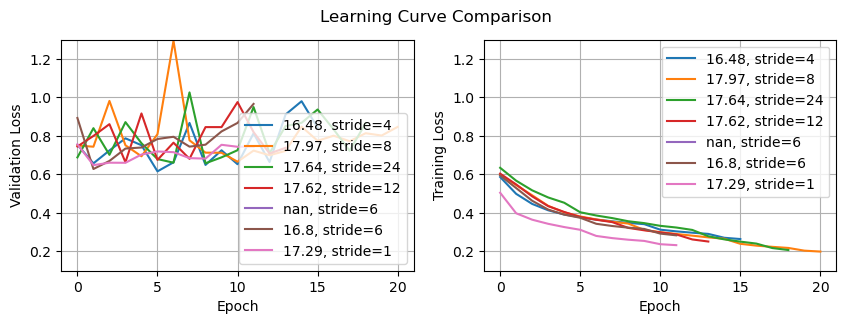

In [35]:
fix, axs = plt.subplots(1,2,figsize=(10, 3))

for _, run in subset.iterrows():
    run_id = run["run_id"]
    run_name = run["tags.mlflow.runName"]
    run_mse = run["metrics.val_MSE_rescaled"]
    stride = run["params.data.stride"]
    history_val = client.get_metric_history(run_id, "val_loss")
    steps_val = [m.step for m in history_val]
    values_val = [m.value for m in history_val]

    history_train = client.get_metric_history(run_id, "train_loss")
    steps_train = [m.step for m in history_train]
    values_train = [m.value for m in history_train]
    
    axs[0].plot(steps_val, values_val, label=f"{round(run_mse,2)}, stride={stride}")
    axs[1].plot(steps_train, values_train, label=f"{round(run_mse,2)}, stride={stride}")

axs[0].set_xlabel("Epoch")
axs[1].set_xlabel("Epoch")

axs[0].set_ylabel("Validation Loss")
axs[1].set_ylabel("Training Loss")

axs[0].set_ylim(0.1,1.3)
axs[1].set_ylim(0.1,1.3)
plt.suptitle("Learning Curve Comparison")
axs[0].legend()
axs[1].legend()

axs[0].grid(True)
axs[1].grid(True)
plt.show()

## AdamW vs Adam

In [36]:
subset = summary_table.query("""`params.shared.seq_len`=='168' & \
    `params.shared.pred_len`=='24' & \
    experiment_id=='2' & \
    `params.data.stride`=='1' & \
    `params.training.optimizer_kwargs.weight_decay`=='0' & \
    `params.model.model_kwargs.kwargs.xlstm_dropout`=='0' & \
    `params.shared.criterion`=='Huber'""")
subset.loc[:,summary_table.columns.to_series().str.startswith("params.training")]

,params.training.mode,params.training.ar_steps,params.training.optimizer,params.training.max_epochs,params.training.optimizer_kwargs.weight_decay,params.training.min_epochs,params.training.optimizer_kwargs.lr,params.training.loss_on,params.training.patience,params.training.batch_size,params.training.criterion
1,single_forecast,0,Adam,100,0,5,0.003,target,10,128,Huber
8,single_forecast,0,Adam,100,0,5,0.003,target,10,128,Huber
9,single_forecast,0,Adam,100,0,5,0.003,target,10,128,Huber
10,single_forecast,0,Adam,100,0,5,0.003,target,10,128,Huber
11,single_forecast,0,Adam,100,0,5,0.003,target,10,128,Huber
32,single_forecast,0,AdamW,100,0,5,0.003,target,10,128,Huber
52,single_forecast,0,Adam,100,0,5,0.003,target,10,128,Huber


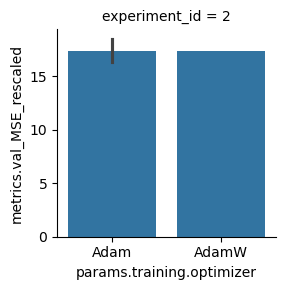

In [37]:
g = sns.FacetGrid(data=subset, col='experiment_id')
g.map_dataframe(sns.barplot, x="params.training.optimizer", y="metrics.val_MSE_rescaled")
g.add_legend()

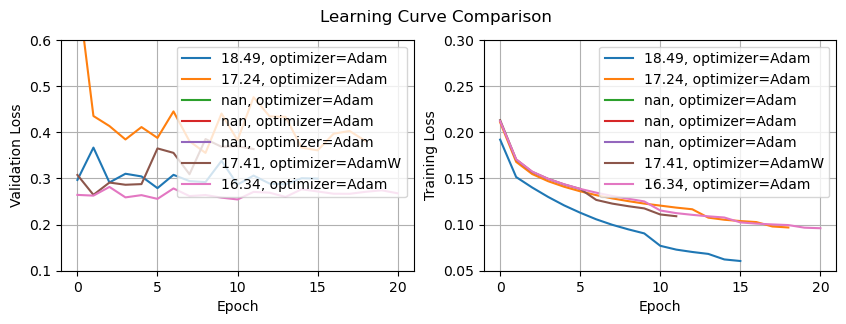

In [38]:
fix, axs = plt.subplots(1,2,figsize=(10, 3))

for _, run in subset.iterrows():
    run_id = run["run_id"]
    run_name = run["tags.mlflow.runName"]
    run_mse = run["metrics.val_MSE_rescaled"]
    optimizer = run["params.training.optimizer"]
    history_val = client.get_metric_history(run_id, "val_loss")
    steps_val = [m.step for m in history_val]
    values_val = [m.value for m in history_val]

    history_train = client.get_metric_history(run_id, "train_loss")
    steps_train = [m.step for m in history_train]
    values_train = [m.value for m in history_train]
    
    axs[0].plot(steps_val, values_val, label=f"{round(run_mse,2)}, optimizer={optimizer}")
    axs[1].plot(steps_train, values_train, label=f"{round(run_mse,2)}, optimizer={optimizer}")

axs[0].set_xlabel("Epoch")
axs[1].set_xlabel("Epoch")

axs[0].set_ylabel("Validation Loss")
axs[1].set_ylabel("Training Loss")

axs[0].set_ylim(0.1,0.6)
axs[1].set_ylim(0.05,0.3)
plt.suptitle("Learning Curve Comparison")
axs[0].legend()
axs[1].legend()

axs[0].grid(True)
axs[1].grid(True)
plt.show()

## 1 block vs 2 blocks

In [42]:
subset = summary_table.query("""`params.shared.seq_len`=='168' & \
    `params.shared.pred_len`=='24' & \
    experiment_id=='2' & \
    `params.data.stride`=='1' & \
    `params.training.optimizer_kwargs.weight_decay`=='0' & \
    `params.model.model_kwargs.kwargs.xlstm_dropout`=='0' & \
    `params.shared.criterion`=='MSE'""")
subset.loc[:,summary_table.columns.to_series().str.startswith("params.model.model_kwargs.kwargs.xlstm_num_blocks")]

,params.model.model_kwargs.kwargs.xlstm_num_blocks
73,3
91,2
92,1


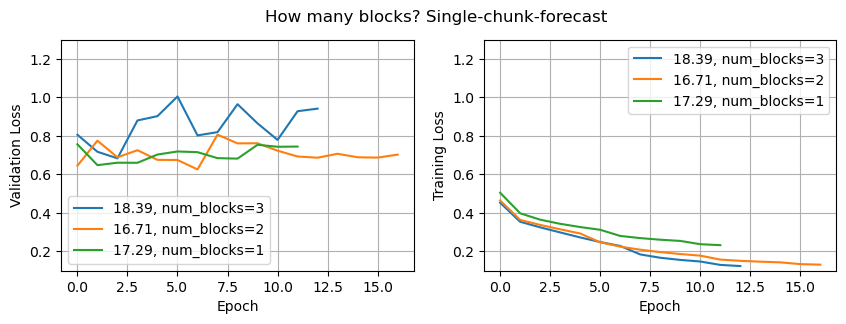

In [43]:
fix, axs = plt.subplots(1,2,figsize=(10, 3))

for _, run in subset.iterrows():
    run_id = run["run_id"]
    run_name = run["tags.mlflow.runName"]
    run_mse = run["metrics.val_MSE_rescaled"]
    num_blocks = run["params.model.model_kwargs.kwargs.xlstm_num_blocks"]
    history_val = client.get_metric_history(run_id, "val_loss")
    steps_val = [m.step for m in history_val]
    values_val = [m.value for m in history_val]

    history_train = client.get_metric_history(run_id, "train_loss")
    steps_train = [m.step for m in history_train]
    values_train = [m.value for m in history_train]
    
    axs[0].plot(steps_val, values_val, label=f"{round(run_mse,2)}, num_blocks={num_blocks}")
    axs[1].plot(steps_train, values_train, label=f"{round(run_mse,2)}, num_blocks={num_blocks}")

axs[0].set_xlabel("Epoch")
axs[1].set_xlabel("Epoch")

axs[0].set_ylabel("Validation Loss")
axs[1].set_ylabel("Training Loss")

axs[0].set_ylim(0.1,1.3)
axs[1].set_ylim(0.1,1.3)
plt.suptitle("How many blocks? Single-chunk-forecast")
axs[0].legend()
axs[1].legend()

axs[0].grid(True)
axs[1].grid(True)
plt.show()

In [44]:
subset = summary_table.query("""`params.shared.seq_len`=='168' & \
    `params.shared.pred_len`=='48' &\
    experiment_id=='1' & \
    `params.data.stride`=='1' & \
    `params.training.optimizer_kwargs.weight_decay`=='0' & \
    `params.model.model_kwargs.kwargs.xlstm_dropout`=='0' & \
    `params.shared.criterion`=='MSE' &\
    `params.training.ar_steps`=='4'""")
subset.loc[:,summary_table.columns.to_series().str.startswith("params.training")]
#subset.loc[subset["experiment_id"]=='1',["params.training.optimizer", "params.model.model_kwargs.kwargs.xlstm_num_blocks"]]

,params.training.max_epochs,params.training.patience,params.training.optimizer_kwargs.weight_decay,params.training.optimizer,params.training.loss_on,params.training.mode,params.training.ar_steps,params.training.batch_size,params.training.min_epochs,params.training.criterion,params.training.optimizer_kwargs.lr,params.training.alpha,params.training.loss_weighted
49,100,10,0,Adam,target,autoregressive,4,128,5,MSE,0.003,None,None
50,100,10,0,Adam,target,autoregressive,4,128,5,MSE,0.003,None,None
88,100,10,0,Adam,target,autoregressive,4,64,5,MSE,0.003,None,None
93,100,10,0,Adam,target,autoregressive,4,128,5,MSE,0.003,None,None


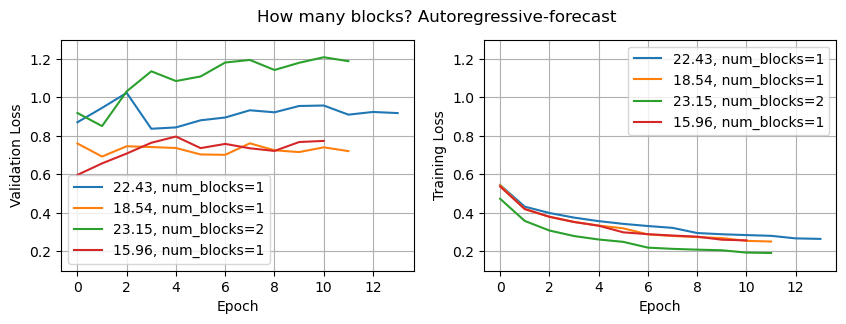

In [45]:
fix, axs = plt.subplots(1,2,figsize=(10, 3))

for _, run in subset.iterrows():
    run_id = run["run_id"]
    run_name = run["tags.mlflow.runName"]
    run_mse = run["metrics.val_MSE_rescaled"]
    num_blocks = run["params.model.model_kwargs.kwargs.xlstm_num_blocks"]
    history_val = client.get_metric_history(run_id, "val_loss")
    steps_val = [m.step for m in history_val]
    values_val = [m.value for m in history_val]

    history_train = client.get_metric_history(run_id, "train_loss")
    steps_train = [m.step for m in history_train]
    values_train = [m.value for m in history_train]
    
    axs[0].plot(steps_val, values_val, label=f"{round(run_mse,2)}, num_blocks={num_blocks}")
    axs[1].plot(steps_train, values_train, label=f"{round(run_mse,2)}, num_blocks={num_blocks}")

axs[0].set_xlabel("Epoch")
axs[1].set_xlabel("Epoch")

axs[0].set_ylabel("Validation Loss")
axs[1].set_ylabel("Training Loss")

axs[0].set_ylim(0.1,1.3)
axs[1].set_ylim(0.1,1.3)
plt.suptitle("How many blocks? Autoregressive-forecast")
axs[0].legend()
axs[1].legend()

axs[0].grid(True)
axs[1].grid(True)
plt.show()

## Num heads

In [49]:
subset = summary_table.query("""`params.shared.seq_len`=='168' & \
    `params.shared.pred_len`=='48' & \
    experiment_id=='2' & \
    `params.data.stride`=='1' & \
    `params.training.optimizer_kwargs.weight_decay`=='0' & \
    `params.model.model_kwargs.kwargs.xlstm_dropout`=='0' & \
    `params.shared.criterion`=='MSE' &\
    `params.model.model_kwargs.kwargs.xlstm_conv1d_kernel_size`.isna() &\
    `params.training.batch_size`=='128'""")
subset.loc[:,summary_table.columns.to_series().str.startswith("params.data")]

,params.data.input,params.data.save_path,params.data.stride,params.data.seq_len,params.data.pred_len,params.data.selected_features
63,all,experiments/,1,168,48,None
85,all,experiments/,1,168,48,None


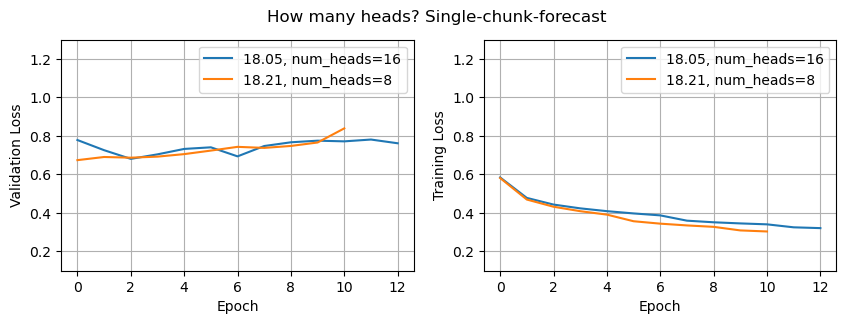

In [50]:
fix, axs = plt.subplots(1,2,figsize=(10, 3))

for _, run in subset.iterrows():
    run_id = run["run_id"]
    run_name = run["tags.mlflow.runName"]
    run_mse = run["metrics.val_MSE_rescaled"]
    num_heads = run["params.model.model_kwargs.kwargs.xlstm_num_heads"]
    history_val = client.get_metric_history(run_id, "val_loss")
    steps_val = [m.step for m in history_val]
    values_val = [m.value for m in history_val]

    history_train = client.get_metric_history(run_id, "train_loss")
    steps_train = [m.step for m in history_train]
    values_train = [m.value for m in history_train]
    
    axs[0].plot(steps_val, values_val, label=f"{round(run_mse,2)}, num_heads={num_heads}")
    axs[1].plot(steps_train, values_train, label=f"{round(run_mse,2)}, num_heads={num_heads}")

axs[0].set_xlabel("Epoch")
axs[1].set_xlabel("Epoch")

axs[0].set_ylabel("Validation Loss")
axs[1].set_ylabel("Training Loss")

axs[0].set_ylim(0.1,1.3)
axs[1].set_ylim(0.1,1.3)
plt.suptitle("How many heads? Single-chunk-forecast")
axs[0].legend()
axs[1].legend()

axs[0].grid(True)
axs[1].grid(True)
plt.show()

In [54]:
subset = summary_table.query("""`params.shared.seq_len`=='168' & \
    `params.shared.pred_len`=='48' & \
    experiment_id=='1' & \
    `params.data.stride`=='1' & \
    `params.training.optimizer_kwargs.weight_decay`=='0' & \
    `params.model.model_kwargs.kwargs.xlstm_dropout`=='0' & \
    `params.shared.criterion`=='MSE' &\
    `params.model.model_kwargs.kwargs.xlstm_conv1d_kernel_size`.isna() &\
    `params.training.ar_steps`=='4' &\
    `params.training.batch_size`=='128'""")
subset.loc[:,summary_table.columns.to_series().str.startswith("params.data")]

,params.data.input,params.data.save_path,params.data.stride,params.data.seq_len,params.data.pred_len,params.data.selected_features
49,all,experiments/,1,168,48,None
93,all,experiments/,1,168,48,None


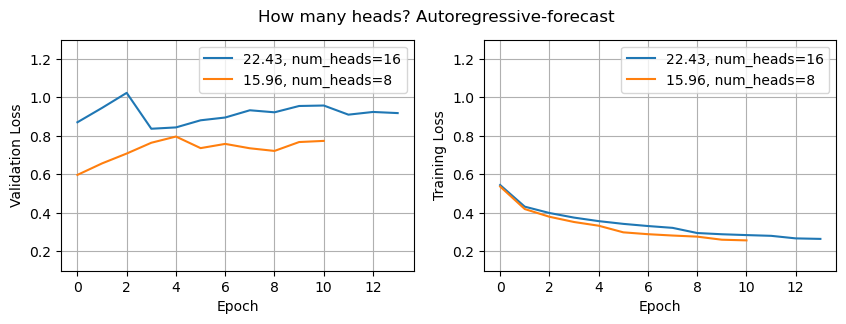

In [56]:
fix, axs = plt.subplots(1,2,figsize=(10, 3))

for _, run in subset.iterrows():
    run_id = run["run_id"]
    run_name = run["tags.mlflow.runName"]
    run_mse = run["metrics.val_MSE_rescaled"]
    num_heads = run["params.model.model_kwargs.kwargs.xlstm_num_heads"]
    history_val = client.get_metric_history(run_id, "val_loss")
    steps_val = [m.step for m in history_val]
    values_val = [m.value for m in history_val]

    history_train = client.get_metric_history(run_id, "train_loss")
    steps_train = [m.step for m in history_train]
    values_train = [m.value for m in history_train]
    
    axs[0].plot(steps_val, values_val, label=f"{round(run_mse,2)}, num_heads={num_heads}")
    axs[1].plot(steps_train, values_train, label=f"{round(run_mse,2)}, num_heads={num_heads}")

axs[0].set_xlabel("Epoch")
axs[1].set_xlabel("Epoch")

axs[0].set_ylabel("Validation Loss")
axs[1].set_ylabel("Training Loss")

axs[0].set_ylim(0.1,1.3)
axs[1].set_ylim(0.1,1.3)
plt.suptitle("How many heads? Autoregressive-forecast")
axs[0].legend()
axs[1].legend()

axs[0].grid(True)
axs[1].grid(True)
plt.show()

## AR forecast steps

In [57]:
subset = summary_table.query("""`params.shared.seq_len`=='168' & \
    `params.shared.pred_len`=='48' & \
    experiment_id=='1' & \
    `params.training.optimizer_kwargs.weight_decay`=='0' & \
    `params.model.model_kwargs.kwargs.xlstm_dropout`=='0' & \
    `params.shared.criterion`=='MSE' &\
    `params.model.model_kwargs.kwargs.xlstm_num_heads`=='8' &\
    `params.model.model_kwargs.kwargs.xlstm_conv1d_kernel_size`!='2'""")
subset.loc[:,summary_table.columns.to_series().str.startswith("params.training")]

,params.training.max_epochs,params.training.patience,params.training.optimizer_kwargs.weight_decay,params.training.optimizer,params.training.loss_on,params.training.mode,params.training.ar_steps,params.training.batch_size,params.training.min_epochs,params.training.criterion,params.training.optimizer_kwargs.lr,params.training.alpha,params.training.loss_weighted
57,100,10,0,Adam,target,autoregressive,6,64,5,MSE,0.003,None,None
87,100,10,0,Adam,target,autoregressive,2,128,5,MSE,0.003,None,None
93,100,10,0,Adam,target,autoregressive,4,128,5,MSE,0.003,None,None


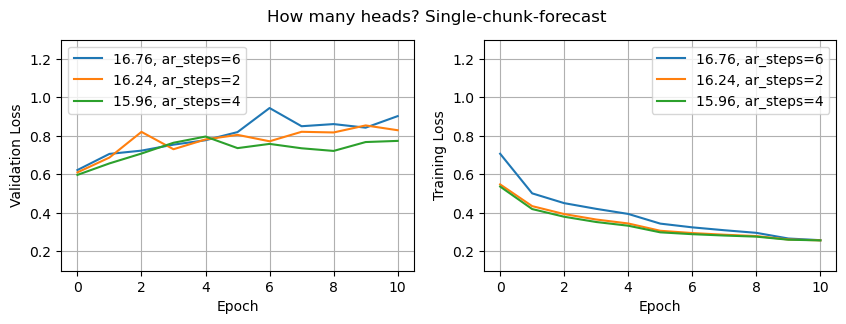

In [58]:
fix, axs = plt.subplots(1,2,figsize=(10, 3))

for _, run in subset.iterrows():
    run_id = run["run_id"]
    run_name = run["tags.mlflow.runName"]
    run_mse = run["metrics.val_MSE_rescaled"]
    ar_steps = run["params.training.ar_steps"]
    history_val = client.get_metric_history(run_id, "val_loss")
    steps_val = [m.step for m in history_val]
    values_val = [m.value for m in history_val]

    history_train = client.get_metric_history(run_id, "train_loss")
    steps_train = [m.step for m in history_train]
    values_train = [m.value for m in history_train]
    
    axs[0].plot(steps_val, values_val, label=f"{round(run_mse,2)}, ar_steps={ar_steps}")
    axs[1].plot(steps_train, values_train, label=f"{round(run_mse,2)}, ar_steps={ar_steps}")

axs[0].set_xlabel("Epoch")
axs[1].set_xlabel("Epoch")

axs[0].set_ylabel("Validation Loss")
axs[1].set_ylabel("Training Loss")

axs[0].set_ylim(0.1,1.3)
axs[1].set_ylim(0.1,1.3)
plt.suptitle("How many heads? Single-chunk-forecast")
axs[0].legend()
axs[1].legend()

axs[0].grid(True)
axs[1].grid(True)
plt.show()

## Batch size

In [62]:
subset = summary_table.query("""`params.shared.seq_len`=='168' & \
    `params.shared.pred_len`=='48' & \
    experiment_id=='2' & \
    `params.data.stride`=='1' & \
    `params.training.optimizer_kwargs.weight_decay`=='0' & \
    `params.model.model_kwargs.kwargs.xlstm_dropout`=='0' & \
    `params.shared.criterion`=='MSE' &\
    `params.model.model_kwargs.kwargs.xlstm_conv1d_kernel_size`.isna() &\
    `params.model.model_kwargs.kwargs.xlstm_num_heads`=='8'""")
subset.loc[:,summary_table.columns.to_series().str.startswith("params.data")]

,params.data.input,params.data.save_path,params.data.stride,params.data.seq_len,params.data.pred_len,params.data.selected_features
61,all,experiments/,1,168,48,None
64,all,experiments/,1,168,48,None
85,all,experiments/,1,168,48,None


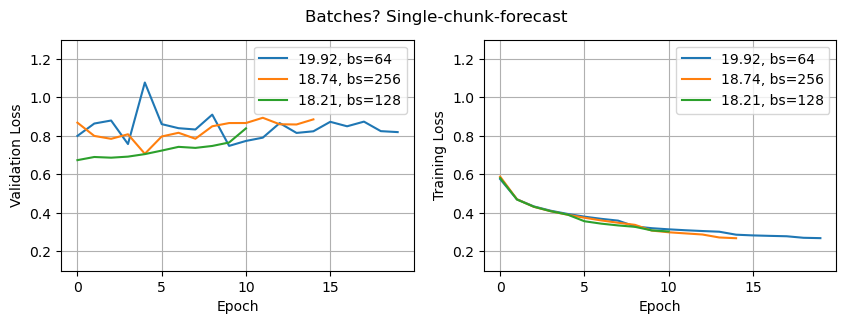

In [63]:
fix, axs = plt.subplots(1,2,figsize=(10, 3))

for _, run in subset.iterrows():
    run_id = run["run_id"]
    run_name = run["tags.mlflow.runName"]
    run_mse = run["metrics.val_MSE_rescaled"]
    bs = run["params.training.batch_size"]
    history_val = client.get_metric_history(run_id, "val_loss")
    steps_val = [m.step for m in history_val]
    values_val = [m.value for m in history_val]

    history_train = client.get_metric_history(run_id, "train_loss")
    steps_train = [m.step for m in history_train]
    values_train = [m.value for m in history_train]
    
    axs[0].plot(steps_val, values_val, label=f"{round(run_mse,2)}, bs={bs}")
    axs[1].plot(steps_train, values_train, label=f"{round(run_mse,2)}, bs={bs}")

axs[0].set_xlabel("Epoch")
axs[1].set_xlabel("Epoch")

axs[0].set_ylabel("Validation Loss")
axs[1].set_ylabel("Training Loss")

axs[0].set_ylim(0.1,1.3)
axs[1].set_ylim(0.1,1.3)
plt.suptitle("Batches? Single-chunk-forecast")
axs[0].legend()
axs[1].legend()

axs[0].grid(True)
axs[1].grid(True)
plt.show()

## Conv1d kernel size?

In [64]:
subset = summary_table.query("""`params.shared.seq_len`=='168' & \
    `params.shared.pred_len`=='48' & \
    experiment_id=='2'&\
    `params.data.stride`=='1' & \
    `params.training.optimizer_kwargs.weight_decay`=='0' & \
    `params.model.model_kwargs.kwargs.xlstm_dropout`=='0' & \
    `params.shared.criterion`=='MSE' &\
    `params.training.batch_size`=='128' &\
    `params.model.model_kwargs.kwargs.xlstm_num_heads`=='8'&\
    `params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1'""")
subset.loc[:,summary_table.columns.to_series().str.startswith("params.model")]

,params.model.model_name,params.model_kwargs.enc_in,params.model.model_kwargs.pred_len,params.model.model_kwargs.seq_len,params.model.prior,params.model.model_kwargs.kwargs.xlstm_num_blocks,params.model.model_kwargs.kwargs.xlstm_num_heads,params.model.base_model_kwargs.cutoff,params.model.prior_as_feature,params.model.model_kwargs.kwargs.xlstm_dropout,params.model.hybrid,params.model.as_feature,params.model.base_model_kwargs.order,params.model.base_model_kwargs.seasonal_order,params.model.base_model_kwargs.trend,params.model.base_model_kwargs.method,params.model.model_kwargs.kwargs.xlstm_conv1d_kernel_size,params.model.model_kwargs.kwargs.xlstm_embedding_dim
48,xLSTMMixer,23,48,168,None,1,8,None,None,0,False,None,None,None,None,None,4,None
65,xLSTMMixer,23,48,168,None,1,8,None,None,0,False,None,None,None,None,None,2,None
85,xLSTMMixer,23,48,168,None,1,8,None,None,0,False,None,None,None,None,None,None,None


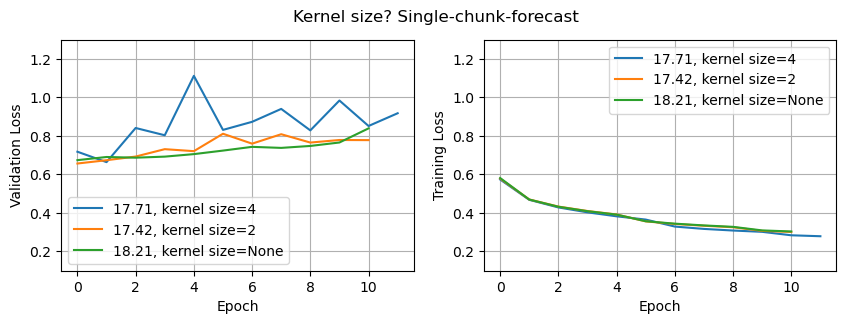

In [65]:
fix, axs = plt.subplots(1,2,figsize=(10, 3))

for _, run in subset.iterrows():
    run_id = run["run_id"]
    run_name = run["tags.mlflow.runName"]
    run_mse = run["metrics.val_MSE_rescaled"]
    kernel_size = run["params.model.model_kwargs.kwargs.xlstm_conv1d_kernel_size"]
    history_val = client.get_metric_history(run_id, "val_loss")
    steps_val = [m.step for m in history_val]
    values_val = [m.value for m in history_val]

    history_train = client.get_metric_history(run_id, "train_loss")
    steps_train = [m.step for m in history_train]
    values_train = [m.value for m in history_train]
    
    axs[0].plot(steps_val, values_val, label=f"{round(run_mse,2)}, kernel size={kernel_size}")
    axs[1].plot(steps_train, values_train, label=f"{round(run_mse,2)}, kernel size={kernel_size}")

axs[0].set_xlabel("Epoch")
axs[1].set_xlabel("Epoch")

axs[0].set_ylabel("Validation Loss")
axs[1].set_ylabel("Training Loss")

axs[0].set_ylim(0.1,1.3)
axs[1].set_ylim(0.1,1.3)
plt.suptitle("Kernel size? Single-chunk-forecast")
axs[0].legend()
axs[1].legend()

axs[0].grid(True)
axs[1].grid(True)
plt.show()

In [69]:
subset = summary_table.query("""`params.shared.seq_len`=='168' & \
    `params.shared.pred_len`=='48' & \
    experiment_id=='1'&\
    `params.data.stride`=='1' & \
    `params.training.optimizer_kwargs.weight_decay`=='0' & \
    `params.model.model_kwargs.kwargs.xlstm_dropout`=='0' & \
    `params.shared.criterion`=='MSE' &\
    `params.training.batch_size`=='128' &\
    `params.training.ar_steps`=='4' &\
    `params.model.model_kwargs.kwargs.xlstm_num_heads`=='8'&\
    `params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1'""")
subset.loc[:,summary_table.columns.to_series().str.startswith("params.model")]

,params.model.model_name,params.model_kwargs.enc_in,params.model.model_kwargs.pred_len,params.model.model_kwargs.seq_len,params.model.prior,params.model.model_kwargs.kwargs.xlstm_num_blocks,params.model.model_kwargs.kwargs.xlstm_num_heads,params.model.base_model_kwargs.cutoff,params.model.prior_as_feature,params.model.model_kwargs.kwargs.xlstm_dropout,params.model.hybrid,params.model.as_feature,params.model.base_model_kwargs.order,params.model.base_model_kwargs.seasonal_order,params.model.base_model_kwargs.trend,params.model.base_model_kwargs.method,params.model.model_kwargs.kwargs.xlstm_conv1d_kernel_size,params.model.model_kwargs.kwargs.xlstm_embedding_dim
50,xLSTMMixer,23,48,168,None,1,8,None,None,0,False,None,None,None,None,None,2,None
93,xLSTMMixer,23,48,168,None,1,8,None,None,0,False,None,None,None,None,None,None,None


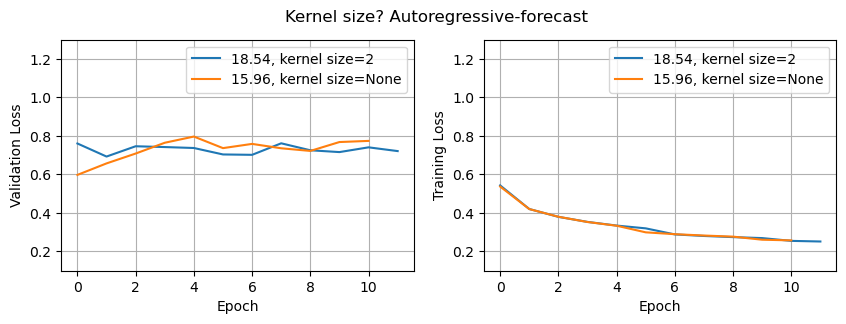

In [71]:
fix, axs = plt.subplots(1,2,figsize=(10, 3))

for _, run in subset.iterrows():
    run_id = run["run_id"]
    run_name = run["tags.mlflow.runName"]
    run_mse = run["metrics.val_MSE_rescaled"]
    kernel_size = run["params.model.model_kwargs.kwargs.xlstm_conv1d_kernel_size"]
    history_val = client.get_metric_history(run_id, "val_loss")
    steps_val = [m.step for m in history_val]
    values_val = [m.value for m in history_val]

    history_train = client.get_metric_history(run_id, "train_loss")
    steps_train = [m.step for m in history_train]
    values_train = [m.value for m in history_train]
    
    axs[0].plot(steps_val, values_val, label=f"{round(run_mse,2)}, kernel size={kernel_size}")
    axs[1].plot(steps_train, values_train, label=f"{round(run_mse,2)}, kernel size={kernel_size}")

axs[0].set_xlabel("Epoch")
axs[1].set_xlabel("Epoch")

axs[0].set_ylabel("Validation Loss")
axs[1].set_ylabel("Training Loss")

axs[0].set_ylim(0.1,1.3)
axs[1].set_ylim(0.1,1.3)
plt.suptitle("Kernel size? Autoregressive-forecast")
axs[0].legend()
axs[1].legend()

axs[0].grid(True)
axs[1].grid(True)
plt.show()

## Loss on all vs target

In [72]:
subset = summary_table.query("""`params.shared.seq_len`=='168' & \
    `params.shared.pred_len`=='24' & \
    experiment_id=='2'&\
    `params.data.stride`=='1' & \
    `params.training.optimizer_kwargs.weight_decay`=='0' & \
    `params.model.model_kwargs.kwargs.xlstm_dropout`=='0' & \
    `params.shared.criterion`=='Huber' &\
    `params.training.batch_size`=='128' &\
    `params.model.model_kwargs.kwargs.xlstm_num_heads`=='8'&\
    `params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1' &\
    `params.training.optimizer`=='Adam'""")

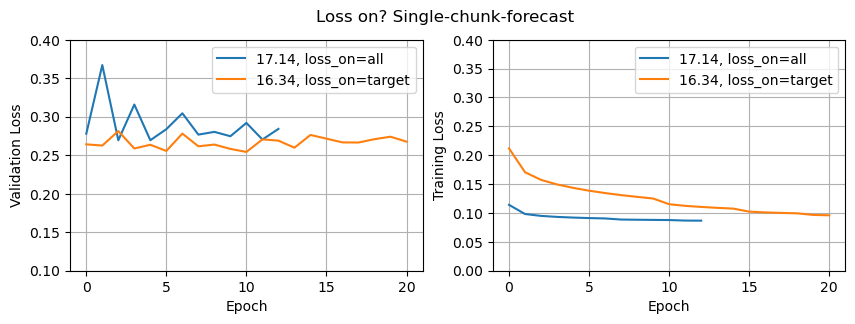

In [73]:
fix, axs = plt.subplots(1,2,figsize=(10, 3))

for _, run in subset.iterrows():
    run_id = run["run_id"]
    run_name = run["tags.mlflow.runName"]
    run_mse = run["metrics.val_MSE_rescaled"]
    loss_on = run["params.training.loss_on"]
    history_val = client.get_metric_history(run_id, "val_loss")
    steps_val = [m.step for m in history_val]
    values_val = [m.value for m in history_val]

    history_train = client.get_metric_history(run_id, "train_loss")
    steps_train = [m.step for m in history_train]
    values_train = [m.value for m in history_train]
    
    axs[0].plot(steps_val, values_val, label=f"{round(run_mse,2)}, loss_on={loss_on}")
    axs[1].plot(steps_train, values_train, label=f"{round(run_mse,2)}, loss_on={loss_on}")

axs[0].set_xlabel("Epoch")
axs[1].set_xlabel("Epoch")

axs[0].set_ylabel("Validation Loss")
axs[1].set_ylabel("Training Loss")

axs[0].set_ylim(0.1,0.4)
axs[1].set_ylim(0,0.4)
plt.suptitle("Loss on? Single-chunk-forecast")
axs[0].legend()
axs[1].legend()

axs[0].grid(True)
axs[1].grid(True)
plt.show()

## All features vs partial features

In [74]:
summary_table.query("`params.data.input`=='partial'").loc[:,summary_table.columns.to_series().str.startswith("params.training")]

,params.training.max_epochs,params.training.patience,params.training.optimizer_kwargs.weight_decay,params.training.optimizer,params.training.loss_on,params.training.mode,params.training.ar_steps,params.training.batch_size,params.training.min_epochs,params.training.criterion,params.training.optimizer_kwargs.lr,params.training.alpha,params.training.loss_weighted
47,100,10,0,Adam,target,autoregressive,4,128,5,Huber,0.003,None,None


In [75]:
subset = summary_table.query("""`params.shared.seq_len`=='168' & \
    `params.shared.pred_len`=='48' & \
    experiment_id=='1'&\
    `params.data.stride`=='1' & \
    `params.training.optimizer_kwargs.weight_decay`=='0' & \
    `params.model.model_kwargs.kwargs.xlstm_dropout`=='0' & \
    `params.shared.criterion`=='Huber' &\
    `params.training.batch_size`=='128' &\
    `params.model.model_kwargs.kwargs.xlstm_num_heads`=='8'&\
    `params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1' &\
    `params.training.optimizer`=='Adam'""")

(<Figure size 1000x300 with 2 Axes>,
 array([<Axes: xlabel='Epoch', ylabel='Validation Loss'>,
        <Axes: xlabel='Epoch', ylabel='Training Loss'>], dtype=object))

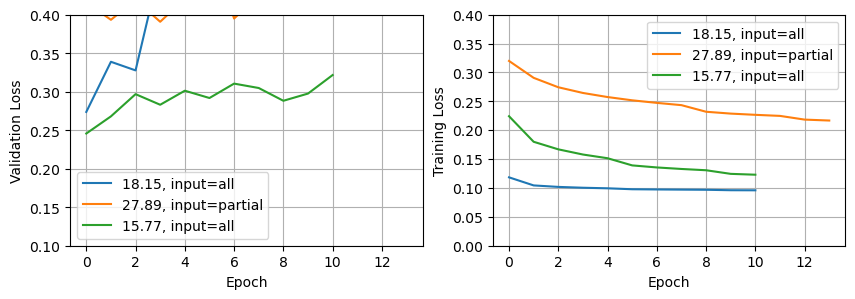

In [76]:
plot_subset(subset, "params.data.input")

In [6]:
## BEST OVERALL
subset = summary_table.sort_values(by="metrics.val_MSE_rescaled")
subset=subset.query("`experiment_id`=='2'")
subset=subset.head(3)
subset.loc[:,subset.columns.to_series().str.startswith("params.model")]

,params.model.model_kwargs.kwargs.xlstm_num_heads,params.model.model_name,params.model.model_kwargs.kwargs.xlstm_dropout,params.model_kwargs.enc_in,params.model.model_kwargs.pred_len,params.model.hybrid,params.model.model_kwargs.kwargs.xlstm_num_blocks,params.model.model_kwargs.seq_len,params.model.prior_as_feature,params.model.base_model_kwargs.cutoff,params.model.prior,params.model.as_feature,params.model.base_model_kwargs.trend,params.model.base_model_kwargs.order,params.model.base_model_kwargs.method,params.model.base_model_kwargs.seasonal_order,params.model.model_kwargs.kwargs.xlstm_conv1d_kernel_size,params.model.model_kwargs.kwargs.xlstm_embedding_dim
7,8,xLSTMMixer,0,23,24,True,2,720,False,15,Fourier,None,None,None,None,None,None,None
23,8,xLSTMMixer,0,23,24,True,2,720,False,15,Fourier,None,None,None,None,None,None,None
6,16,xLSTMMixer,0.1,23,24,True,2,720,False,20,Fourier,None,None,None,None,None,None,None


## Unsorted

In [ ]:
derived = summary_table.loc[summary_table["params.meta.phase"]=='follow_up_1',["tags.mlflow.runName", "params.meta.derived_from_run_name", "metrics.val_MSE_rescaled", "metrics.val_MAE_rescaled"]]
#summary_table["params.meta.phase"]

,tags.mlflow.runName,params.meta.derived_from_run_name,metrics.val_MSE_rescaled,metrics.val_MAE_rescaled
1,legendary-stork-486,mercurial-perch-230,18.640038,3.089448
2,sneaky-fish-711,dashing-mink-136,17.611277,3.016820
3,tasteful-yak-952,monumental-stag-381,20.754980,3.466874
4,selective-turtle-187,secretive-stork-371,22.595476,3.493761
5,legendary-calf-562,handsome-hog-487,18.016642,3.108948


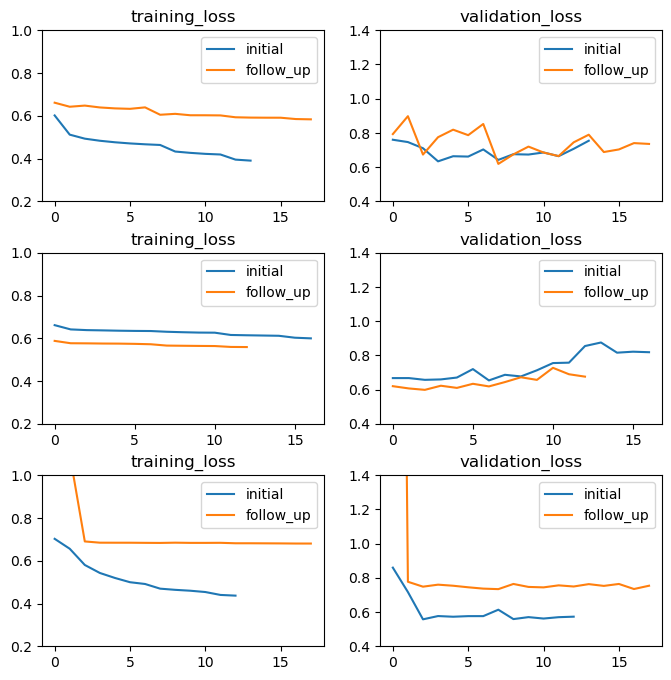

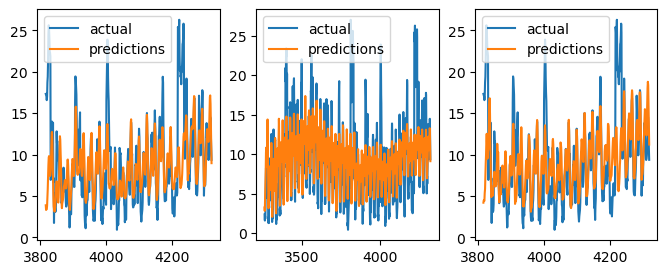

In [4]:
fig, axs = plt.subplots(3,2,figsize=(8,8))

orig =["invincible-mule-348", "adaptable-turtle-560", "enchanting-hound-255"]
derived = ["puzzled-lamb-733", "casual-lamb-144", "charming-dolphin-562"]

for i in range(len(orig)):
    orig_name = orig[i]
    der_name = derived[i]
    run_id_0 = summary_table.loc[summary_table["tags.mlflow.runName"]==orig_name,"run_id"].values[0]
    run_id_1 = summary_table.loc[summary_table["tags.mlflow.runName"]==der_name,"run_id"].values[0]

    history_val_0 = client.get_metric_history(run_id_0, "val_loss")
    steps_val_0 = [m.step for m in history_val_0]
    values_val_0 = [m.value for m in history_val_0]
    history_train_0 = client.get_metric_history(run_id_0, "train_loss")
    steps_train_0 = [m.step for m in history_train_0]
    values_train_0 = [m.value for m in history_train_0]

    history_val_1 = client.get_metric_history(run_id_1, "val_loss")
    steps_val_1 = [m.step for m in history_val_1]
    values_val_1 = [m.value for m in history_val_1]
    history_train_1 = client.get_metric_history(run_id_1, "train_loss")
    steps_train_1 = [m.step for m in history_train_1]
    values_train_1 = [m.value for m in history_train_1]

    axs[i,0].plot(steps_train_0, values_train_0, label="initial")
    axs[i,0].plot(steps_train_1, values_train_1, label="follow_up")
    axs[i,0].set_title("training_loss")
    axs[i,0].set_ylim(0.2, 1)
    axs[i,0].legend()

    axs[i,1].plot(steps_val_0, values_val_0, label="initial")
    axs[i,1].plot(steps_val_1, values_val_1, label="follow_up")
    axs[i,1].set_title("validation_loss")
    axs[i,1].set_ylim(0.4, 1.4)
    axs[i,1].legend()

plt.subplots_adjust(hspace=0.3)

fig, axs = plt.subplots(1,3,figsize=(8,3))

for i in range(len(orig)):
    orig_name = orig[i]
    der_name = derived[i]
    save_dir_0 = summary_table.loc[summary_table["tags.mlflow.runName"]==orig_name,"params.save_dir"].values[0]
    save_dir_1 = summary_table.loc[summary_table["tags.mlflow.runName"]==der_name,"params.save_dir"].values[0]

    raw_preds_0 = pd.read_csv(os.path.join(save_dir_0, "raw_preds.csv"), index_col=0)
    #raw_preds_1 = pd.read_csv(os.path.join(save_dir_1, "raw_preds.csv"), index_col=0)
    group_000 = raw_preds_0.groupby("series_id").get_group("unit_000")
    axs[i].plot(group_000["target_actual"], label="actual")
    axs[i].plot(group_000["target_pred"], label="predictions")
    axs[i].legend()

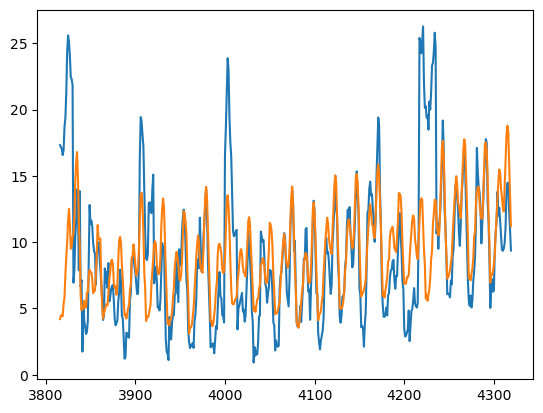

In [34]:
name = "loud-snail-319"
run_id = summary_table.loc[summary_table["tags.mlflow.runName"]==name,"run_id"].values[0]
save_dir = summary_table.loc[summary_table["tags.mlflow.runName"]==name,"params.save_dir"].values[0]
raw_preds = pd.read_csv(os.path.join(save_dir, "raw_preds.csv"), index_col=0)
group_000 = raw_preds_0.groupby("series_id").get_group("unit_000")
plt.plot(group_000["target_actual"], label="actual")
plt.plot(group_000["target_pred"], label="predictions")

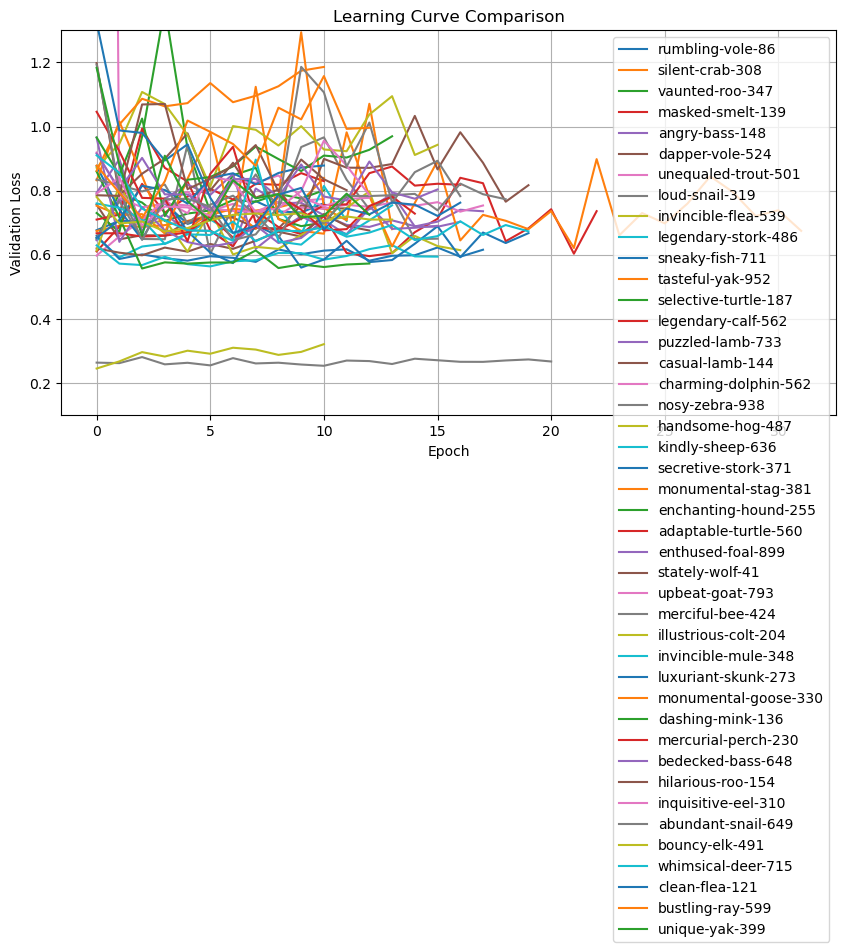

In [35]:

plt.figure(figsize=(10, 5))

for _, run in summary_table.iterrows():
    run_id = run["run_id"]
    run_name = run["tags.mlflow.runName"]
    #if run_name != "kindly-sheep-636":
        #continue
    history = client.get_metric_history(run_id, "val_loss")
    steps = [m.step for m in history]
    values = [m.value for m in history]
    
    plt.plot(steps, values, label=run_name)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.ylim(0.1,1.3)
plt.title("Learning Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [31]:
metrics_list = []
for run in summary_table["run_id"].values:
    try:
        path=client.download_artifacts(run_id=run, path="metrics.csv")
        metrics = pd.read_csv(path, index_col=0)
        metrics["run_id"] = run
        metrics_list.append(metrics)
    except Exception:
        continue

total_metrics_df = pd.concat(metrics_list)

In [32]:
total_metrics_df

,MSE,RMSE,MAE,MAPE,WAPE,sMAPE,run_id
0,16.340883,4.042386,2.938565,0.406536,0.298795,0.333185,11d6f6c68b404932a242fd7fb539d1be
0,18.640038,4.317411,3.089449,0.371484,0.295546,0.325412,8ec795d9e0404a16af7ea63a12e485a4
0,17.611277,4.196579,3.016820,0.383242,0.288599,0.320700,0812452f8b7b4a3ea45bca99bce35d86
0,20.754980,4.555763,3.466874,0.536727,0.352514,0.381940,d4bfd3bbe5ee48e38c8e98b9170ebf2d
0,22.595476,4.753470,3.493761,0.474116,0.355248,0.384709,b1432b1840ec4cc39d3b4c60db2f1649
0,18.016642,4.244601,3.108948,0.413069,0.297412,0.329408,3dbd30b66bc84d579a46cb75f4c1d9fd
0,18.227444,4.269361,3.133563,0.413660,0.299766,0.332567,af686d6ab93c4c79a466f9663eb16a6e
0,16.568030,4.070385,2.901846,0.395172,0.295062,0.328013,f4da86217b434f5496e3ea61d623d6f9
0,19.663137,4.434314,3.222873,0.433271,0.327704,0.358205,13788a0a043746f58c178c5dee1c85b3
0,19.764309,4.445707,3.161448,0.350025,0.302434,0.331471,351e4e78e0e544438171b94930809775


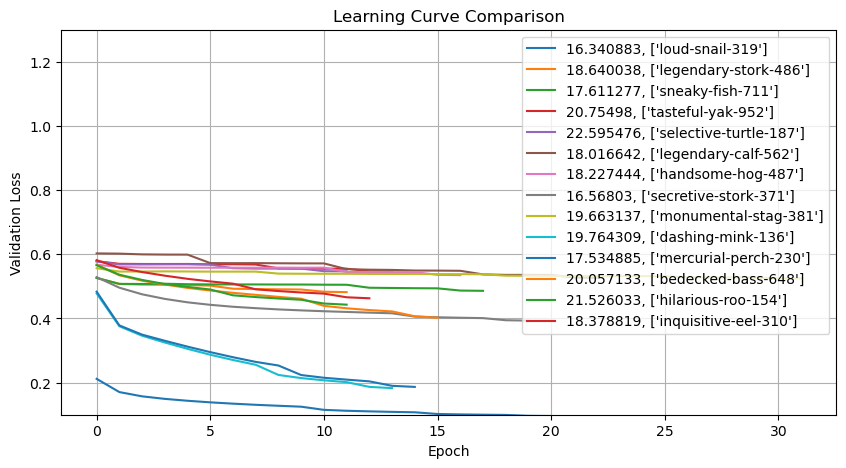

In [ ]:
plt.figure(figsize=(10, 5))

for _, run in total_metrics_df.iterrows():
    run_id = rdata=total_metrics_df, un["run_id"]
    run_name = summary_table.loc[summary_table["run_id"]==run_id,"tags.mlflow.runName"].values
    run_mse = run["MSE"]
    history = client.get_metric_history(run_id, "train_loss")
    steps = [m.step for m in history]
    values = [m.value for m in history]
    
    plt.plot(steps, values, label=f"{run_mse}, {run_name}")

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.ylim(0.1,1.3)
plt.title("Learning Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
import seaborn as sns

trained_on_list=[]
for i, run in total_metrics_df.iterrows():
    run_id = run["run_id"]
    trained_on = summary_table.loc[(summary_table["run_id"]==run_id), "params.shared.criterion"].values[0]
    trained_on_list.append(trained_on)
    #run_name = summary_table.loc[summary_table["run_id"]==run_id,"tags.mlflow.runName"].values

total_metrics_df["trained_on"] = trained_on_list

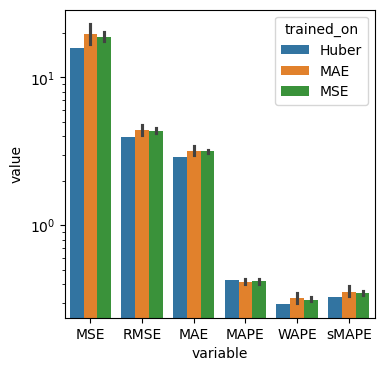

In [13]:
plot_df = total_metrics_df.melt(id_vars=["trained_on", "run_id"])
fig, ax = plt.subplots(1,1,figsize=(4,4))
sns.barplot(data=plot_df, x="variable", y="value", hue="trained_on", ax=ax)
ax.set_yscale('log')

In [14]:
summary_table.loc[:,["tags.mlflow.runName", "experiment_id", "params.shared.pred_len", "params.shared.seq_len", "params.data.stride"]]

,tags.mlflow.runName,experiment_id,params.shared.pred_len,params.shared.seq_len,params.data.stride
0,invincible-flea-539,1,48,168,1
1,puzzled-lamb-733,1,48,168,1
2,casual-lamb-144,1,96,720,1
3,charming-dolphin-562,1,48,168,24
4,nosy-zebra-938,1,48,168,1
6,kindly-sheep-636,1,48,168,1
8,enchanting-hound-255,1,48,168,24
9,adaptable-turtle-560,1,96,720,1
10,enthused-foal-899,1,48,168,1
11,stately-wolf-41,1,48,168,24


Initial runs to try:
Autoregressive:
    - something like invincible mule but with stride 12
    - stride 24, pred_len 24, seq_len 720, MAE
    - pred_len 72, seq_len 720, MAE
    - seq_len 336, pred_len 24, MAE
    - seq_len 336, pred_len 48, MAE

Single-chunk:
    - pred_len 48, seq_len 720, MAE

BEST OF PHASE 1
Autoregressive:
train all on MAE
- adaptable-turtle-560 
- kindly sheep 636 
- enchanting hound 
- enthused foal with higher learning rate
- invincible mule with higher learning rate and regularization

Single-chunk:
- mercurial pearch with regularization
- handsome hog with a little bit less regularization
- monumental stag with regularization and higher learning rate
- secretive stork with minimally larger learning rate and regularization
- dashing mink with regularization


In [64]:
subset = summary_table[["experiment_id","run_id","tags.mlflow.runName","params.model.model_kwargs.seq_len", "params.model.model_kwargs.pred_len", "params.shared.criterion","params.training.optimizer_kwargs.lr", "params.training.optimizer_kwargs.weight_decay", "params.model.model_kwargs.kwargs.xlstm_dropout", "params.training.batch_size", "params.data.stride", "params.training.ar_steps", "params.model.model_kwargs.kwargs.xlstm_num_blocks"]]
subset = subset.rename(columns = lambda x: x.split(".")[-1])
runs_of_interest = [
    "mercurial-perch-230",
    "handsome-hog-487",
    "secretive-stork-371",
    "monumental-stag-381",
    "dashing-mink-136",
    "adaptable-turtle-560",
    "kindly-sheep-636",
    "enchanting-hound-255",
    "enthused-foal-899",
    "invincible-mule-348"
]
subset.query("runName in @runs_of_interest")

,experiment_id,run_id,runName,seq_len,pred_len,criterion,lr,weight_decay,xlstm_dropout,batch_size,stride,ar_steps,xlstm_num_blocks
0,2,af686d6ab93c4c79a466f9663eb16a6e,handsome-hog-487,720,24,MAE,0.005,0.01,0.25,128,1,0,1
1,1,863d318a74ee4290a77faea6b8c38958,kindly-sheep-636,168,48,MAE,0.005,0.0001,0.1,128,1,4,1
2,2,f4da86217b434f5496e3ea61d623d6f9,secretive-stork-371,168,24,MAE,0.0005,0.0001,0.1,128,1,0,1
3,2,13788a0a043746f58c178c5dee1c85b3,monumental-stag-381,168,24,MAE,0.001,0.01,0.2,128,1,0,1
8,1,4e9ef4814ce54a4cb39fb1ad3db1a674,enchanting-hound-255,168,48,MAE,0.005,0.0001,0.1,128,24,4,1
9,1,cfc73e52937646578be499f0dc8974ae,adaptable-turtle-560,720,96,MSE,0.001,0.01,0.25,128,1,2,1
10,1,dcb77f71dbc544c4af20322d88c0d801,enthused-foal-899,168,48,MSE,0.01,0.0001,0.1,128,1,4,1
17,1,4a3c2e725bb84cb49a1030c7dcfacf4d,invincible-mule-348,168,48,MSE,0.005,0.0001,0.1,128,1,4,1
23,2,351e4e78e0e544438171b94930809775,dashing-mink-136,720,24,MSE,0.0005,0.0001,0.1,128,1,0,2
24,2,81c5220fa28d4edda35bee47f80f3498,mercurial-perch-230,720,24,MSE,0.0005,0.0001,0.1,128,1,0,2


Observations:
- one of the lowest validation loss achieved with stride=24, definitely try others with stride 24 -> training speed up
Planned:
Single-chunk:
- handsome-hog with dropout 0.2, batch size 64 and learning rate 0.005
- monumental stag with lr 0.005, dropout 0.1
- secretive stork with lr 0.005, weight decay 0.01
- dashing-mink with MAE, lr 0.001 and weight_decay 0.01
- mercurial perch with MAE lr 0.001 and weight_decay 0.01

Autoregressive:
- kindly sheep with dropout 0.2 and weight_decay 0.01
- enchanting hound with lr 0.05
- adaptable turtle with dropout 0.1 and MAE
- enthused foal with weight_decay 0.01 and MAE
- invincible-mule with MAE and wieght_decay 0.01

In [65]:
run = mlflow.get_run("af686d6ab93c4c79a466f9663eb16a6e")
flat_params = run.data.params

In [7]:
plot_link = client.download_artifacts(run_id="863d318a74ee4290a77faea6b8c38958", path="pred_plots.png")

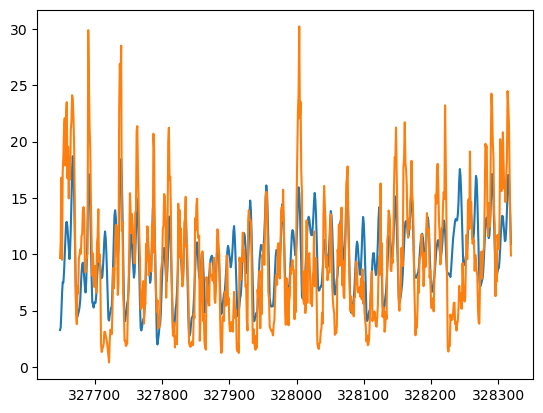

In [29]:
pred_path ="experiments/xLSTMMixer_90a5961e_ab874efe01114e18a05ce06be0214162/predictions.csv"
target_path = "experiments/xLSTMMixer_90a5961e_ab874efe01114e18a05ce06be0214162/target.csv"
df_pred = pd.read_csv(pred_path, index_col=0)
df_target = pd.read_csv(target_path, index_col=0)
groups_pred = df_pred.groupby("series_id")
groups_target = df_target.groupby("series_id")
unit_pred = groups_pred.get_group("unit_075")
unit_target = groups_target.get_group("unit_075")

plt.plot(unit_pred["target"])
plt.plot(unit_target["target"])
#plt.savefig("experiments/xLSTMMixer_90a5961e_ab874efe01114e18a05ce06be0214162/unit_075_preds.png", format='PNG')

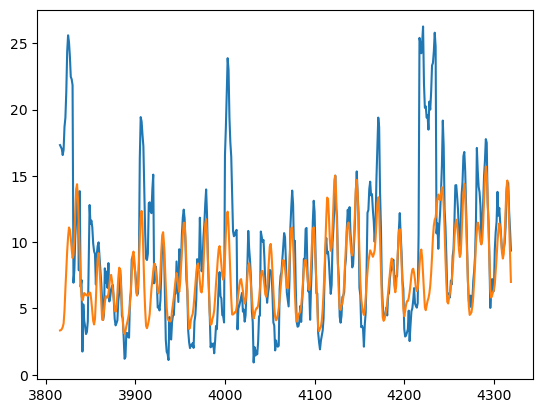

In [84]:
pred_path='experiments/xLSTMMixer_ba668fe8_07016a4ab7fa4f389061544aa4813db6/raw_preds.csv'
df_pred = pd.read_csv(pred_path, index_col=0)
groups = df_pred.groupby('series_id').get_group('unit_000')
plt.plot(groups["target_actual"])
plt.plot(groups["target_pred"])